Estimation de l'effet causal de la fermeture des établissement 'social' sur le vote RN à l'aide d'un staggered DID

Import des bibliothèques

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from did_multiplegt_dyn import DidMultiplegtDyn  

Import des données

In [2]:
# Social
df_rnp_social = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
df_rnp_social['codecommune'] = df_rnp_social['codecommune'].astype(str).str.zfill(5)

df_rp_social = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
df_rp_social['codecommune'] = df_rp_social['codecommune'].astype(str).str.zfill(5)

df_ui_social = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)
df_ui_social['codecommune'] = df_ui_social['codecommune'].astype(str).str.zfill(5)

df_ud_social = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_d.csv", index_col=0)
df_ud_social['codecommune'] = df_ud_social['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_26900\4143535900.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp_social = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_26900\4143535900.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp_social = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_26900\4143535900.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui_social = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)


In [3]:
# Social
df_rnp_transactionnel = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)
df_rnp_transactionnel['codecommune'] = df_rnp_transactionnel['codecommune'].astype(str).str.zfill(5)

df_rp_transactionnel = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rp.csv", index_col=0)
df_rp_transactionnel['codecommune'] = df_rp_transactionnel['codecommune'].astype(str).str.zfill(5)

df_ui_transactionnel = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_ui.csv", index_col=0)
df_ui_transactionnel['codecommune'] = df_ui_transactionnel['codecommune'].astype(str).str.zfill(5)

df_ud_transactionnel = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_d.csv", index_col=0)
df_ud_transactionnel['codecommune'] = df_ud_transactionnel['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_26900\3592169386.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp_transactionnel = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_26900\3592169386.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp_transactionnel = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_26900\3592169386.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui_transactionnel = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transacti

Fonction d'attribution du traitement

In [4]:
def traitement(df,seuil):
    # 1. On définit notre seuil de traitement à partir de l'année 2002
    df_2002 = df[df['Annee'] == 1998].copy()
    df_2002['seuil'] = df_2002['total_equipements'] * seuil

    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['seuil']
    df['seuil'] = df['codecommune'].map(mapping_seuil)

    # 3. Première passe : condition simple (1 si on passe sous le seuil, 0 sinon)
    if seuil < 1 :
        df['traitée'] = (df['total_equipements'] < df['seuil']).astype(int)
    elif seuil > 1 :
        df['traitée'] = (df['total_equipements'] > df['seuil']).astype(int)

    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])

    # 5. L'EFFET CLIQUET : On applique un maximum cumulé par commune.
    # Dès qu'une commune obtient un 1, toutes les lignes suivantes pour cette commune vaudront 1.
    df['traitée'] = df.groupby('codecommune')['traitée'].cummax()

    return df

## DID

Definition du modele

In [5]:
def DID (df, election, annee_deb, parti,seuil) :
    # 0. Definition du traitement
    df = traitement(df,seuil)

    # 1. On filtre la base pour ne garder que les années d'élection présidentielle
    annees_pres = [annee_deb, 2002, 2007, 2012, 2017, 2022]
    df_pres = df[df['Annee'].isin(annees_pres)].copy()

    # 2. Nettoyage : on retire les lignes avec des valeurs manquantes essentielles
    df_pres = df_pres.dropna(subset=[f'vote_{parti}_{election}', 'traitée'])

    # 3. On force les types en formats "simples" (Numpy) pour faciliter la conversion
    # (Cela vous évite l'erreur PyArrow)
    df_pres[f'vote_{parti}_{election}'] = df_pres[f'vote_{parti}_{election}'].astype('float64')
    df_pres['traitée'] = df_pres['traitée'].astype('float64')
    df_pres['Annee'] = df_pres['Annee'].astype('int64')
    # Note : S'il y a un souci avec 'codecommune' (par exemple si c'est un format 'object'),
    # vous pouvez aussi le forcer en string classique : df_pres['codecommune'] = df_pres['codecommune'].astype('str')

    # 4. Conversion en Polars
    df_pres_polars = pl.from_pandas(df_pres)

    # 5. Estimation Staggered DiD (avec le nom de classe corrigé)
    modele_did = DidMultiplegtDyn(
        df=df_pres_polars,         
        outcome=f'vote_{parti}_{election}',    # Variable dépendante
        group='codecommune',       # Identifiant du groupe
        time='Annee',              # Variable temporelle
        treatment='traitée',       # Indicateur de traitement
        placebo=2,                 # Tester 1 période avant le traitement (pre-trends)
        effects=5,                 # Estimer l'effet sur les 2 périodes suivant le traitement
        cluster='codecommune',      # Clustering des erreurs-types
        controls = ['pop', 'propf', 'prop014', 'prop1539', 'prop60p', 'petranger', 'pouem', 'pchom', 'paind','pbac', 'psup', 'revmoy']
    )

    modele_did.fit()
    modele_did.summary()
    modele_did.plot()
    return 

# Social

## Diminution

### RN

#### Presidentielles

##### 40%

In [6]:
seuil = 1 - 0.4

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000852 0.000710 -0.000539 0.002243 37217.0     4754.0 37217.0       4754.0
            Effect_2  0.004088 0.000943  0.002241 0.005935 28154.0     4241.0 28154.0       4241.0
            Effect_3  0.007969 0.001262  0.005496 0.010442 20379.0     3646.0 20379.0       3646.0
            Effect_4  0.012173 0.001701  0.008840 0.015506 13188.0     2680.0 13188.0       2680.0
            Effect_5  0.014658 0.002516  0.009727 0.019589  6196.0     1308.0  6196.0       1308.0
Average_Total_Effect  0.006148 0.000947  0.004292 0.008004 49111.0    16629.0 49111.0      16629.0
           Placebo_1  0.000349 0.000802 -0.001223 0.001922 27297.0     3401.0 27297.0       3401.0
           Placebo_2 -0.000869 0.001361 -0.003535 0.001798 12032.0     1534.0 12032.0       1534.0
Test of joint nullity of the effects: p-val

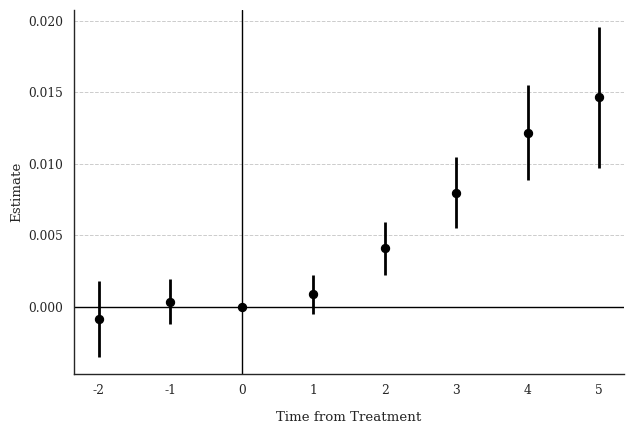

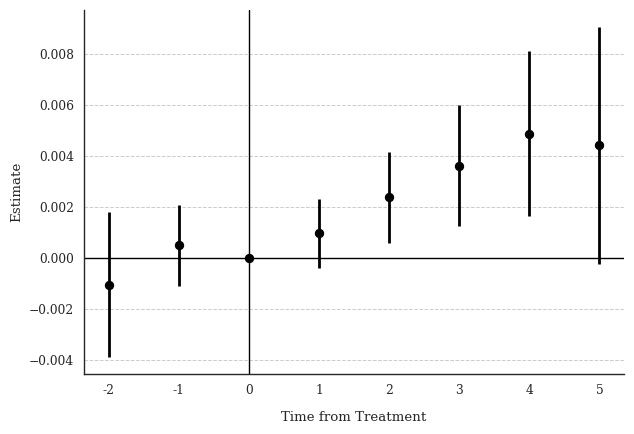

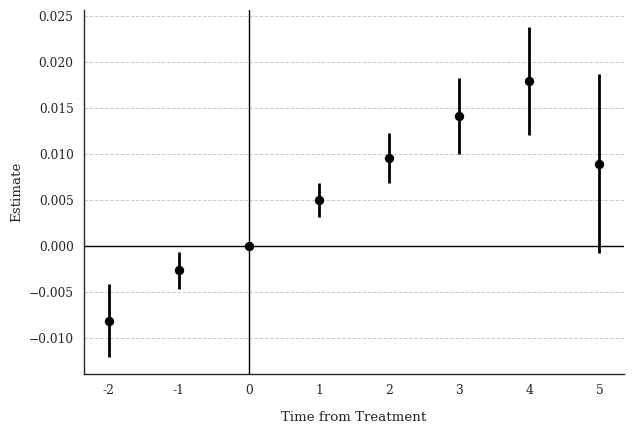

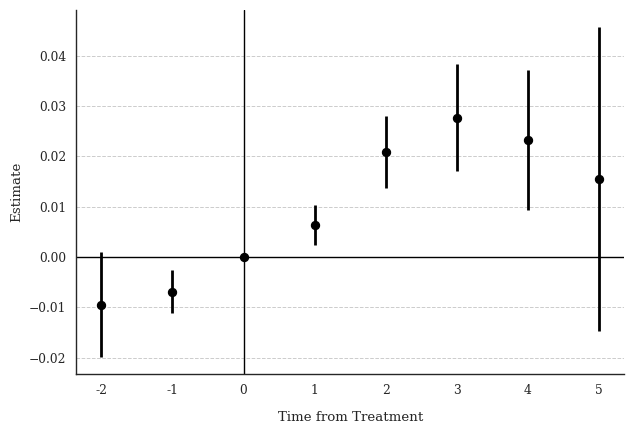

In [7]:
DID(df_rnp_social, 'pres', 1995, 'RN',seuil)
DID(df_rp_social, 'pres', 1995, 'RN',seuil)
DID(df_ui_social, 'pres', 1995, 'RN',seuil)
DID(df_ud_social, 'pres', 1995, 'RN',seuil)

##### 30%

In [8]:
seuil = 1 - 0.3

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000351 0.000713 -0.001046 0.001748 33045.0     4784.0 33045.0       4784.0
            Effect_2  0.003044 0.000936  0.001210 0.004879 24975.0     4356.0 24975.0       4356.0
            Effect_3  0.005020 0.001257  0.002556 0.007484 18225.0     3841.0 18225.0       3841.0
            Effect_4  0.007963 0.001670  0.004690 0.011237 11983.0     2959.0 11983.0       2959.0
            Effect_5  0.009988 0.002399  0.005287 0.014689  5736.0     1546.0  5736.0       1546.0
Average_Total_Effect  0.004188 0.000966  0.002294 0.006082 45763.0    17486.0 45763.0      17486.0
           Placebo_1  0.001358 0.000844 -0.000297 0.003013 23798.0     3194.0 23798.0       3194.0
           Placebo_2  0.001205 0.001476 -0.001688 0.004097 10389.0     1373.0 10389.0       1373.0
Test of joint nullity of the effects: p-val

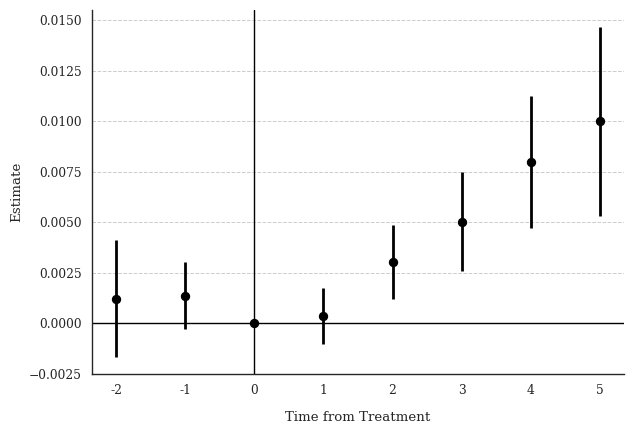

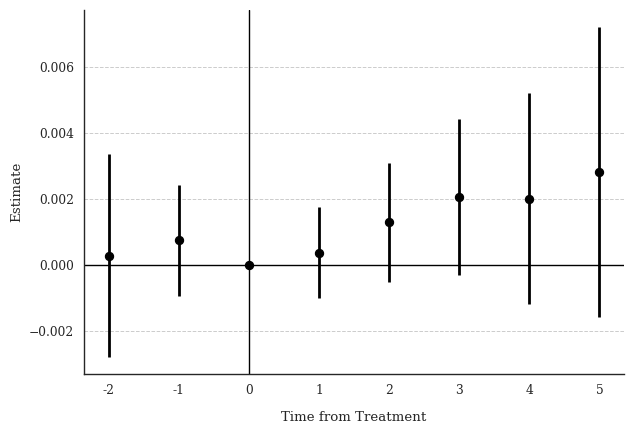

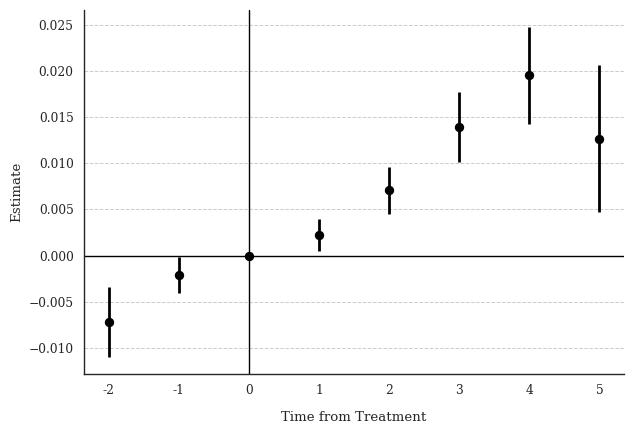

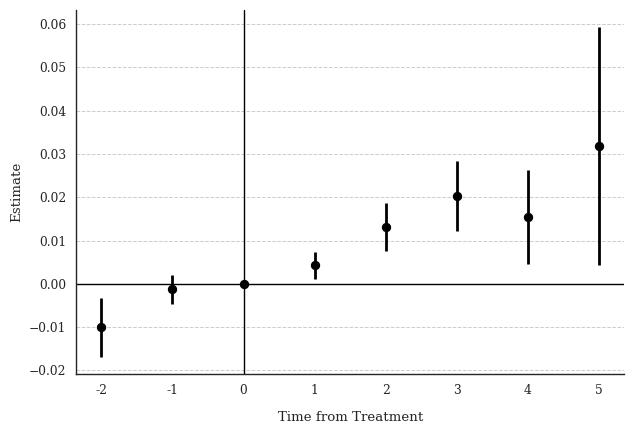

In [9]:
DID(df_rnp_social, 'pres', 1995, 'RN',seuil)
DID(df_rp_social, 'pres', 1995, 'RN',seuil)
DID(df_ui_social, 'pres', 1995, 'RN',seuil)
DID(df_ud_social, 'pres', 1995, 'RN',seuil)

##### 50%

In [10]:
seuil = 1 - 0.5

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.001265 0.000757 -0.000219 0.002750 43694.0     4174.0 43694.0       4174.0
            Effect_2  0.005369 0.001017  0.003375 0.007362 33291.0     3564.0 33291.0       3564.0
            Effect_3  0.009376 0.001353  0.006724 0.012027 23997.0     2932.0 23997.0       2932.0
            Effect_4  0.014253 0.001903  0.010523 0.017983 15330.0     1989.0 15330.0       1989.0
            Effect_5  0.018331 0.003005  0.012442 0.024220  7115.0      865.0  7115.0        865.0
Average_Total_Effect  0.007107 0.000973  0.005199 0.009015 53064.0    13524.0 53064.0      13524.0
           Placebo_1 -0.000643 0.000830 -0.002269 0.000983 32979.0     3270.0 32979.0       3270.0
           Placebo_2 -0.002573 0.001366 -0.005251 0.000104 14874.0     1546.0 14874.0       1546.0
Test of joint nullity of the effects: p-val

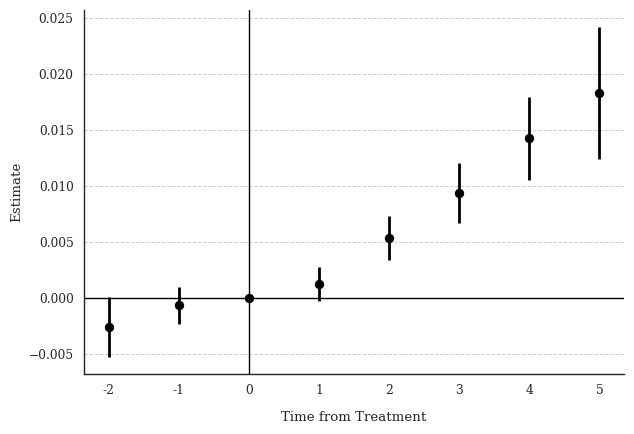

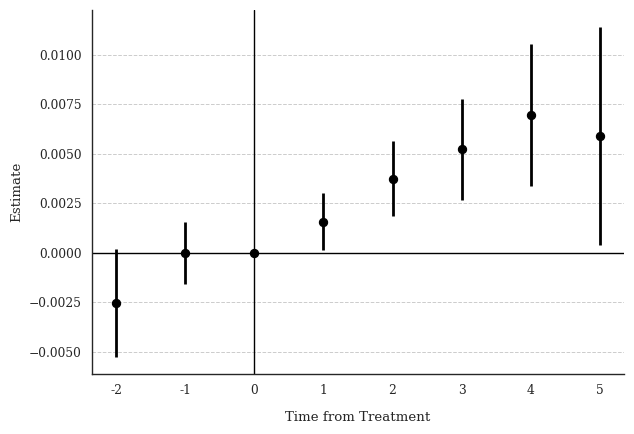

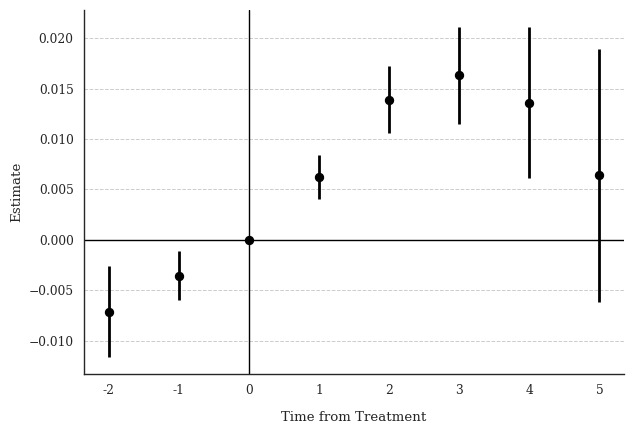

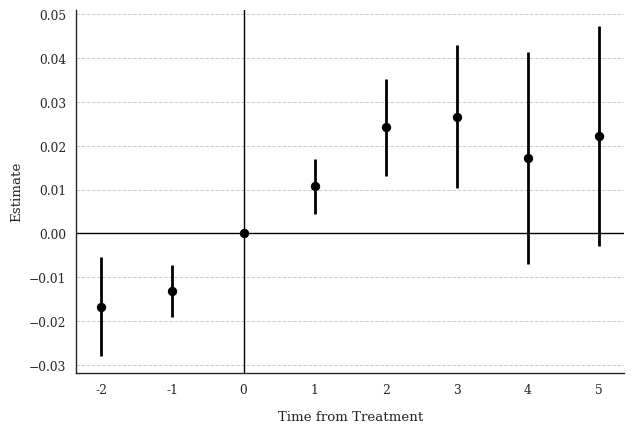

In [11]:
DID(df_rnp_social, 'pres', 1995, 'RN',seuil)
DID(df_rp_social, 'pres', 1995, 'RN',seuil)
DID(df_ui_social, 'pres', 1995, 'RN',seuil)
DID(df_ud_social, 'pres', 1995, 'RN',seuil)

#### Legislatives

In [12]:
seuil = 1 - 0.4

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.001361 0.000765 -0.000138 0.002860 37170.0     4660.0 37170.0       4660.0
            Effect_2  0.002637 0.001028  0.000622 0.004653 28098.0     4147.0 28098.0       4147.0
            Effect_3  0.004844 0.001347  0.002205 0.007483 20316.0     3551.0 20316.0       3551.0
            Effect_4  0.009241 0.001790  0.005732 0.012749 13124.0     2586.0 13124.0       2586.0
            Effect_5  0.010122 0.002884  0.004470 0.015774  6127.0     1214.0  6127.0       1214.0
Average_Total_Effect  0.004373 0.000954  0.002504 0.006243 48682.0    16158.0 48682.0      16158.0
           Placebo_1  0.000247 0.000843 -0.001404 0.001899 27348.0     3409.0 27348.0       3409.0
           Placebo_2  0.000028 0.001414 -0.002743 0.002799 12067.0     1536.0 12067.0       1536.0
Test of joint nullity of the effects: p-val

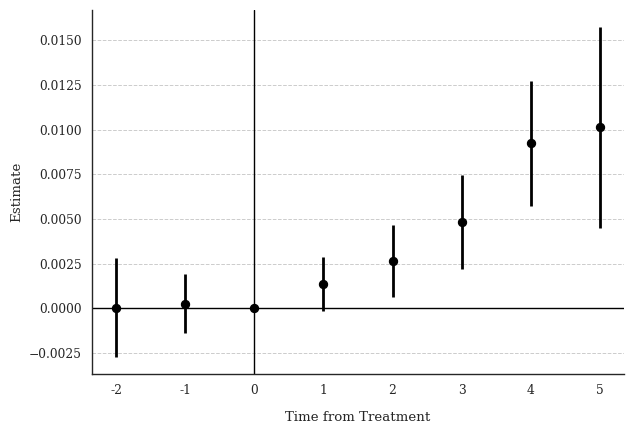

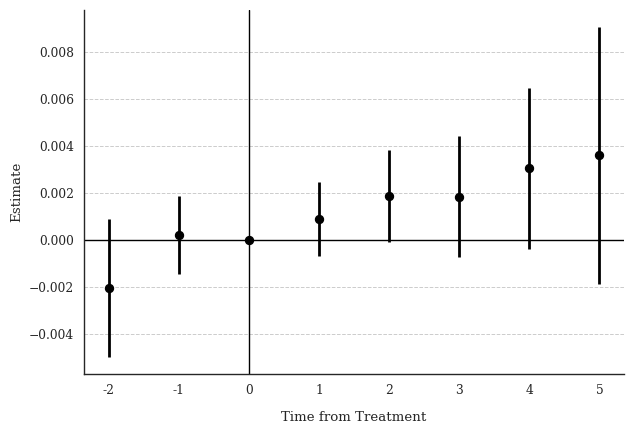

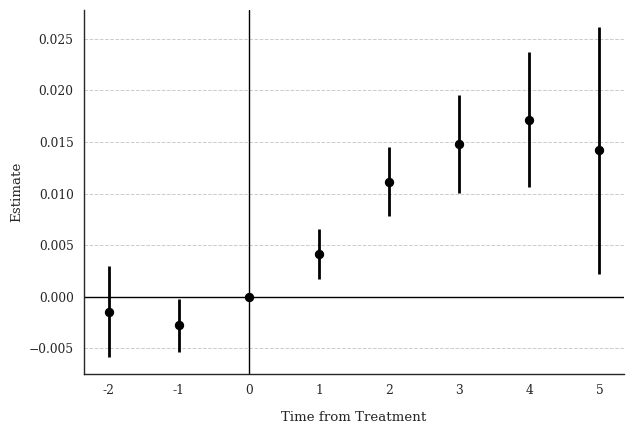

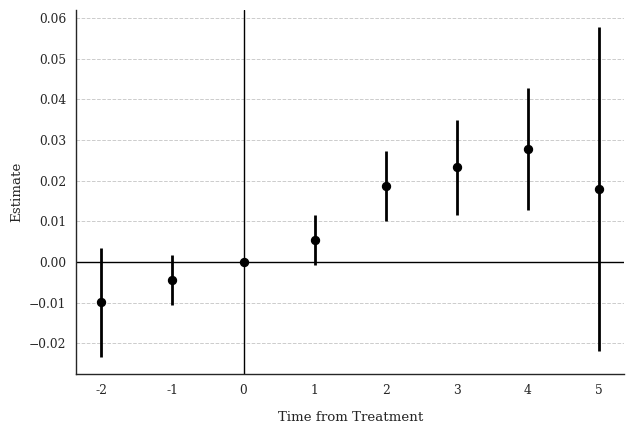

In [13]:
DID(df_rnp_social, 'leg', 1997, 'RN',seuil)
DID(df_rp_social, 'leg', 1997, 'RN',seuil)
DID(df_ui_social, 'leg', 1997, 'RN',seuil)
DID(df_ud_social, 'leg', 1997, 'RN',seuil)

##### 30%

In [14]:
seuil = 1 - 0.3

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.001275 0.000768 -0.000231 0.002781 32938.0     4634.0 32938.0       4634.0
            Effect_2  0.001947 0.001020 -0.000052 0.003947 24861.0     4207.0 24861.0       4207.0
            Effect_3  0.002630 0.001336  0.000011 0.005248 18106.0     3691.0 18106.0       3691.0
            Effect_4  0.005596 0.001762  0.002142 0.009050 11864.0     2810.0 11864.0       2810.0
            Effect_5  0.006407 0.002778  0.000962 0.011852  5612.0     1397.0  5612.0       1397.0
Average_Total_Effect  0.002896 0.000978  0.000980 0.004813 45055.0    16739.0 45055.0      16739.0
           Placebo_1  0.000216 0.000879 -0.001506 0.001939 23844.0     3201.0 23844.0       3201.0
           Placebo_2 -0.000116 0.001518 -0.003092 0.002860 10422.0     1374.0 10422.0       1374.0
Test of joint nullity of the effects: p-val

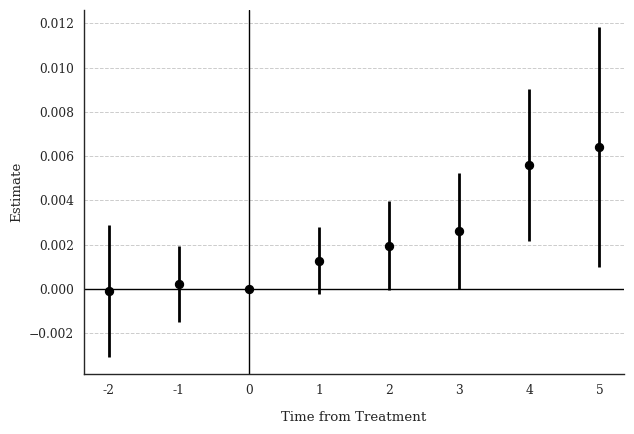

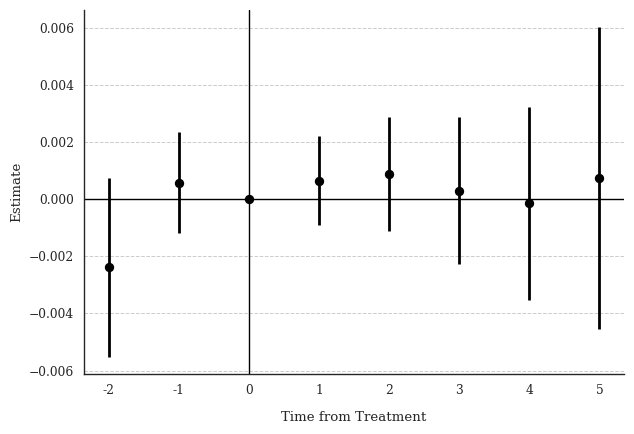

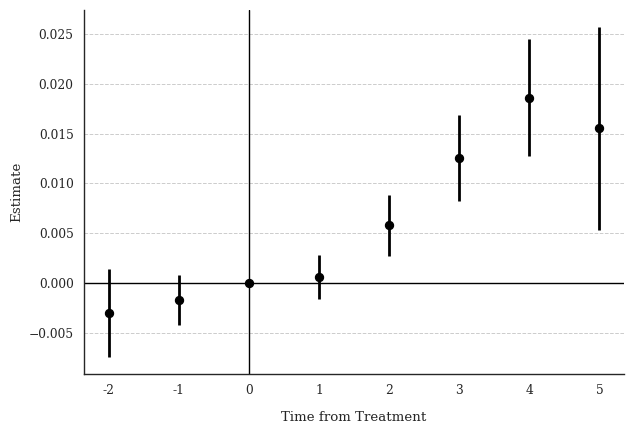

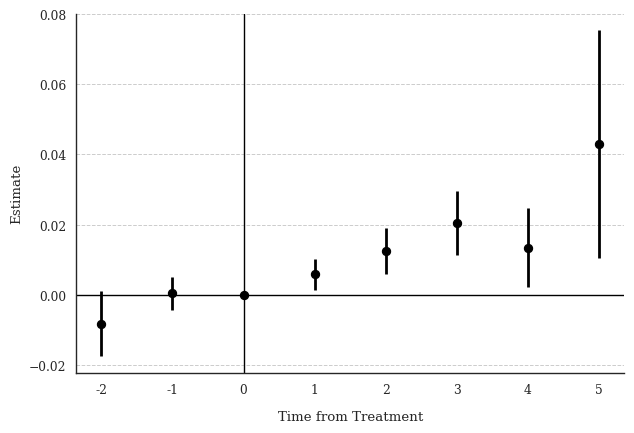

In [15]:
DID(df_rnp_social, 'leg', 1997, 'RN',seuil)
DID(df_rp_social, 'leg', 1997, 'RN',seuil)
DID(df_ui_social, 'leg', 1997, 'RN',seuil)
DID(df_ud_social, 'leg', 1997, 'RN',seuil)

##### 50%

In [16]:
seuil = 1 - 0.5

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.001396 0.000826 -0.000224 0.003015 43696.0     4128.0 43696.0       4128.0
            Effect_2  0.002484 0.001118  0.000292 0.004676 33285.0     3518.0 33285.0       3518.0
            Effect_3  0.004710 0.001456  0.001855 0.007564 23982.0     2885.0 23982.0       2885.0
            Effect_4  0.011217 0.001995  0.007307 0.015126 15310.0     1945.0 15310.0       1945.0
            Effect_5  0.015815 0.003417  0.009118 0.022511  7087.0      818.0  7087.0        818.0
Average_Total_Effect  0.004727 0.000982  0.002803 0.006651 52876.0    13294.0 52876.0      13294.0
           Placebo_1 -0.001274 0.000882 -0.003004 0.000455 33032.0     3277.0 33032.0       3277.0
           Placebo_2 -0.000965 0.001412 -0.003732 0.001802 14906.0     1549.0 14906.0       1549.0
Test of joint nullity of the effects: p-val

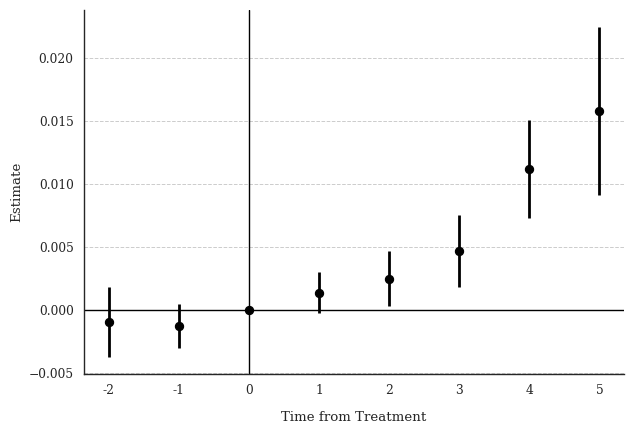

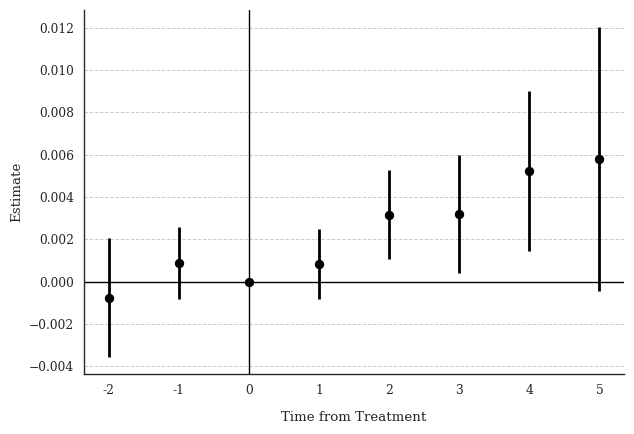

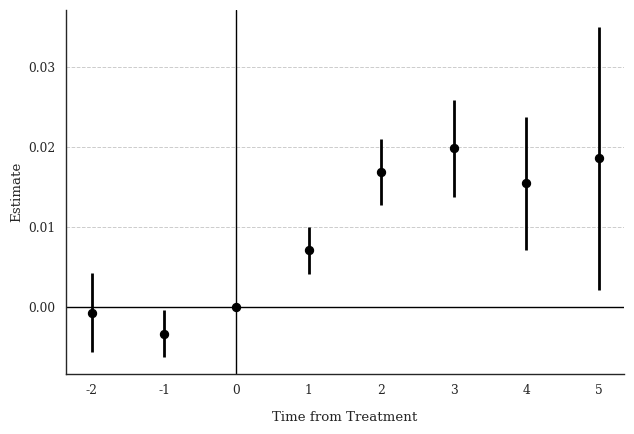

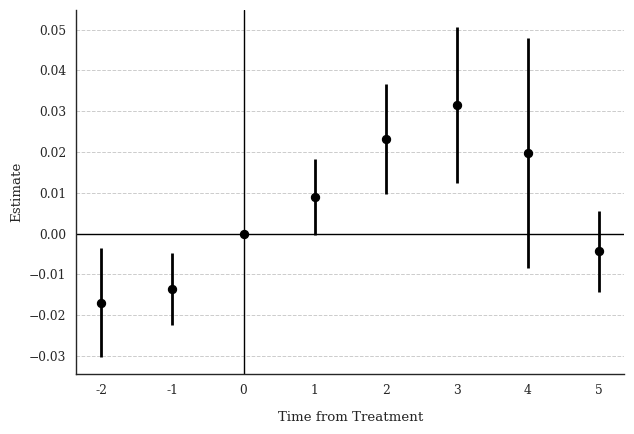

In [17]:
DID(df_rnp_social, 'leg', 1997, 'RN',seuil)
DID(df_rp_social, 'leg', 1997, 'RN',seuil)
DID(df_ui_social, 'leg', 1997, 'RN',seuil)
DID(df_ud_social, 'leg', 1997, 'RN',seuil)

### PS

#### Presidentielles

In [18]:
seuil = 1 - 0.4

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000101 0.000811 -0.001490  0.001691 37217.0     4754.0 37217.0       4754.0
            Effect_2  0.000360 0.001092 -0.001780  0.002499 28154.0     4241.0 28154.0       4241.0
            Effect_3  0.001340 0.001217 -0.001046  0.003726 20379.0     3646.0 20379.0       3646.0
            Effect_4  0.001637 0.001478 -0.001260  0.004534 13188.0     2680.0 13188.0       2680.0
            Effect_5  0.002826 0.002415 -0.001907  0.007560  6196.0     1308.0  6196.0       1308.0
Average_Total_Effect  0.000901 0.000921 -0.000905  0.002706 49111.0    16629.0 49111.0      16629.0
           Placebo_1 -0.001465 0.000967 -0.003359  0.000430 27297.0     3401.0 27297.0       3401.0
           Placebo_2 -0.005878 0.001613 -0.009039 -0.002717 12032.0     1534.0 12032.0       1534.0
Test of joint nullity of the effec

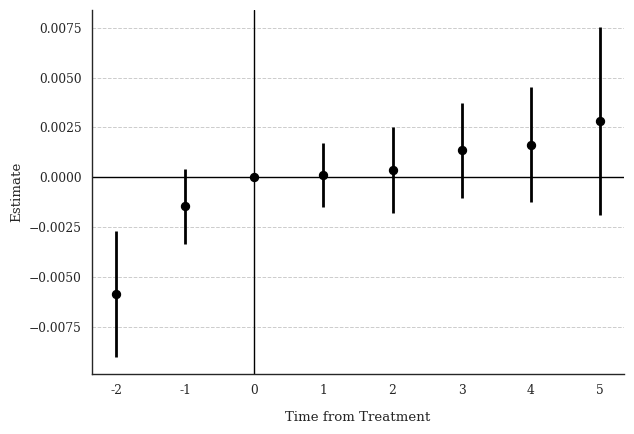

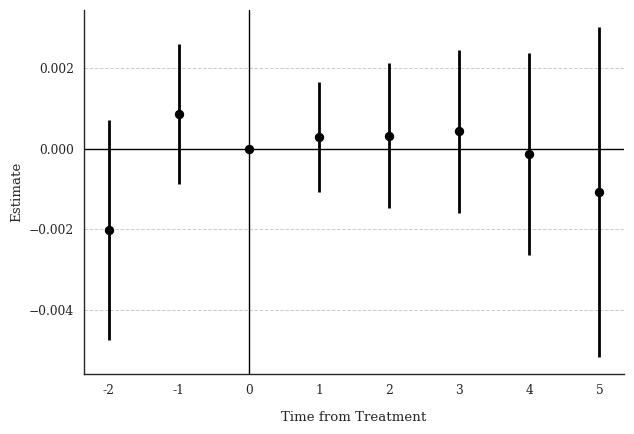

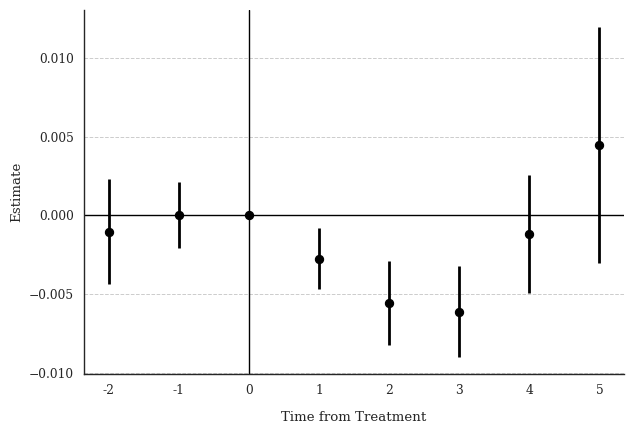

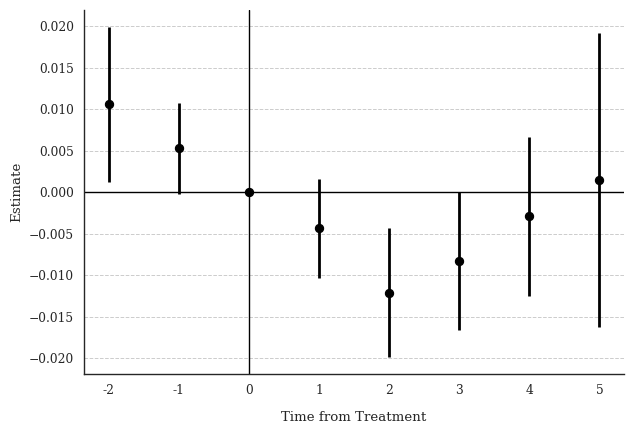

In [19]:
DID(df_rnp_social, 'pres', 1995, 'PS',seuil)
DID(df_rp_social, 'pres', 1995, 'PS',seuil)
DID(df_ui_social, 'pres', 1995, 'PS',seuil)
DID(df_ud_social, 'pres', 1995, 'PS',seuil)

#### Legislatives

In [20]:
seuil = 1 - 0.4

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.001836 0.002015 -0.002112 0.005785 37170.0     4660.0 37170.0       4660.0
            Effect_2  0.000257 0.002603 -0.004846 0.005359 28098.0     4147.0 28098.0       4147.0
            Effect_3  0.000676 0.002968 -0.005141 0.006494 20316.0     3551.0 20316.0       3551.0
            Effect_4 -0.001192 0.003481 -0.008016 0.005631 13124.0     2586.0 13124.0       2586.0
            Effect_5 -0.000871 0.005234 -0.011129 0.009387  6127.0     1214.0  6127.0       1214.0
Average_Total_Effect  0.000488 0.002110 -0.003647 0.004622 48682.0    16158.0 48682.0      16158.0
           Placebo_1 -0.004426 0.002300 -0.008934 0.000082 27348.0     3409.0 27348.0       3409.0
           Placebo_2 -0.002957 0.004101 -0.010994 0.005081 12067.0     1536.0 12067.0       1536.0
Test of joint nullity of the effects: p-val

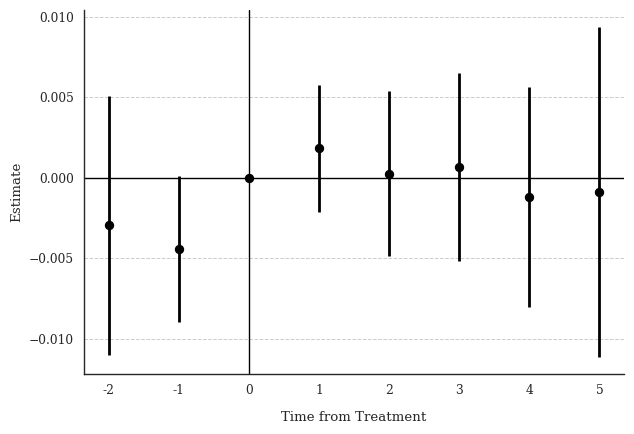

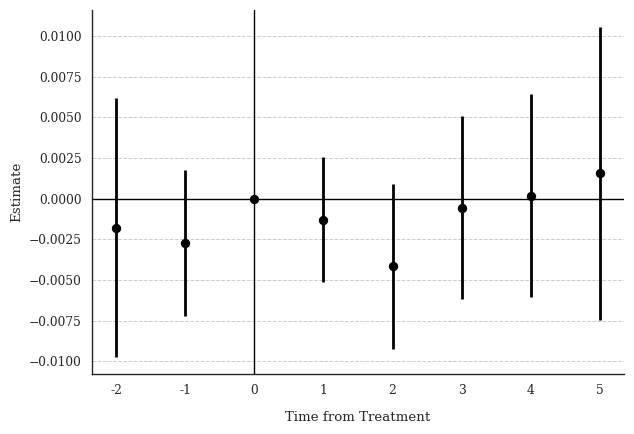

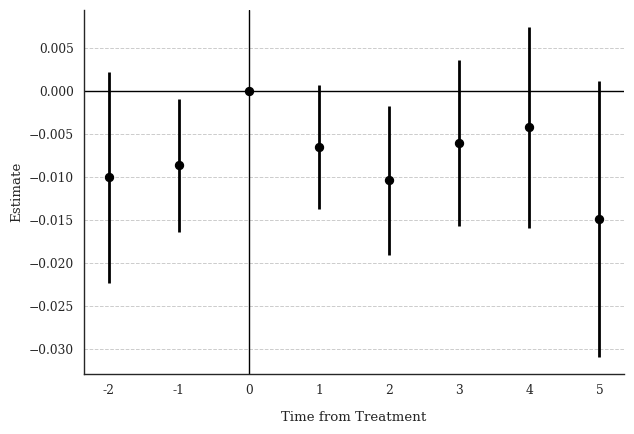

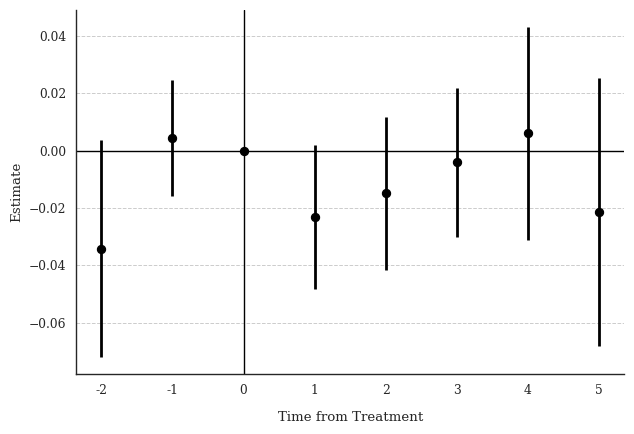

In [21]:
DID(df_rnp_social, 'leg', 1997, 'PS',seuil)
DID(df_rp_social, 'leg', 1997, 'PS',seuil)
DID(df_ui_social, 'leg', 1997, 'PS',seuil)
DID(df_ud_social, 'leg', 1997, 'PS',seuil)

## Augmentation

### RN

#### Presidentielles

##### 20%

In [22]:
seuil = 1 + 0.2

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002363 0.000634 -0.003605 -0.001120 36233.0     6334.0 36233.0       6334.0
            Effect_2 -0.005071 0.000834 -0.006705 -0.003437 27569.0     5750.0 27569.0       5750.0
            Effect_3 -0.006000 0.001095 -0.008147 -0.003853 20424.0     5165.0 20424.0       5165.0
            Effect_4 -0.008640 0.001434 -0.011450 -0.005829 13863.0     4330.0 13863.0       4330.0
            Effect_5 -0.009377 0.001863 -0.013028 -0.005725  7225.0     2814.0  7225.0       2814.0
Average_Total_Effect -0.005695 0.000867 -0.007394 -0.003995 54304.0    24393.0 54304.0      24393.0
           Placebo_1  0.000958 0.000865 -0.000737  0.002654 25280.0     3472.0 25280.0       3472.0
           Placebo_2  0.000640 0.001541 -0.002380  0.003661 10907.0     1380.0 10907.0       1380.0
Test of joint nullity of the effec

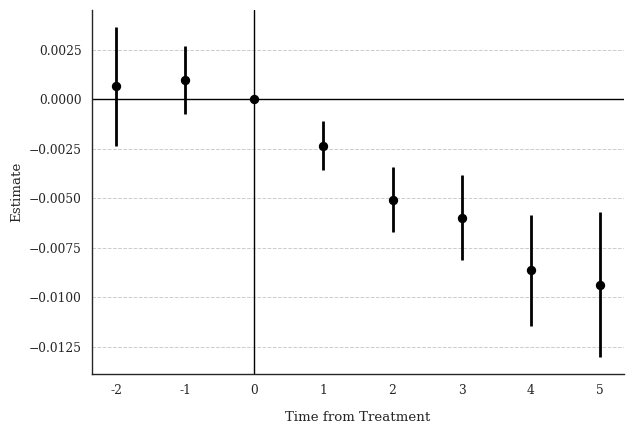

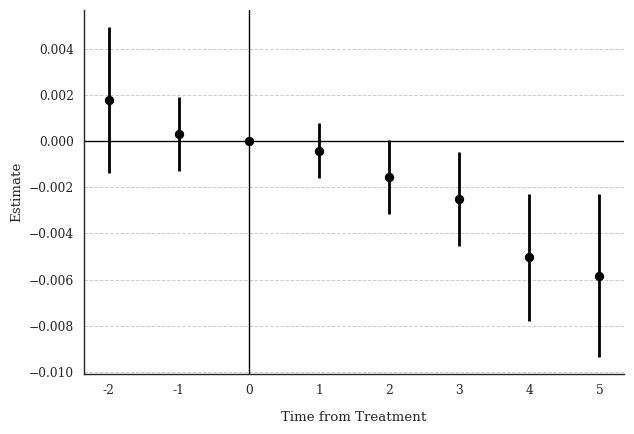

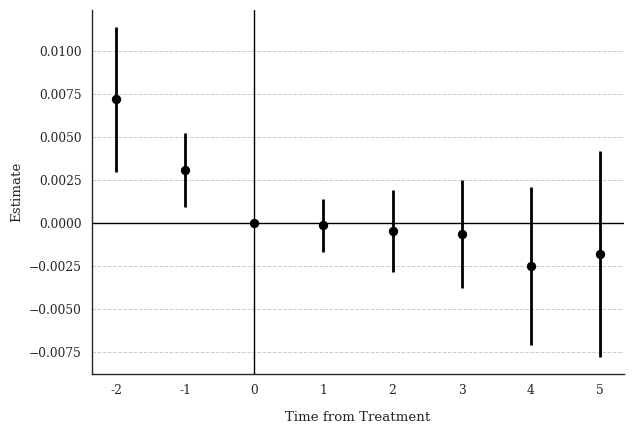

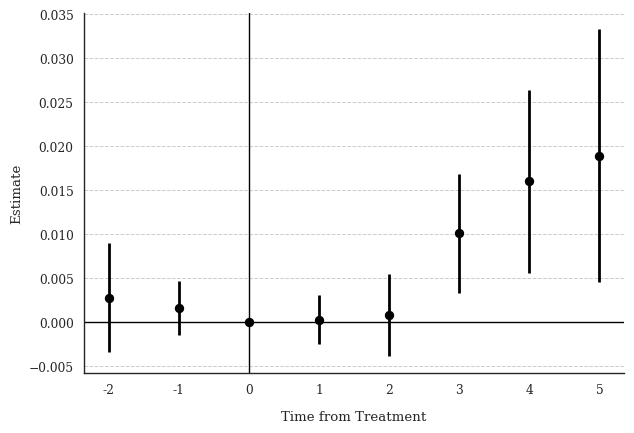

In [23]:
DID(df_rnp_social, 'pres', 1995, 'RN',seuil)
DID(df_rp_social, 'pres', 1995, 'RN',seuil)
DID(df_ui_social, 'pres', 1995, 'RN',seuil)
DID(df_ud_social, 'pres', 1995, 'RN',seuil)

##### 30%

In [24]:
seuil = 1 + 0.3

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002498 0.000650 -0.003772 -0.001225 37947.0     5984.0 37947.0       5984.0
            Effect_2 -0.004280 0.000848 -0.005942 -0.002619 28900.0     5401.0 28900.0       5401.0
            Effect_3 -0.004216 0.001108 -0.006387 -0.002044 21313.0     4796.0 21313.0       4796.0
            Effect_4 -0.005867 0.001442 -0.008693 -0.003042 14329.0     3971.0 14329.0       3971.0
            Effect_5 -0.005748 0.001909 -0.009489 -0.002007  7319.0     2496.0  7319.0       2496.0
Average_Total_Effect -0.004236 0.000867 -0.005935 -0.002537 54623.0    22648.0 54623.0      22648.0
           Placebo_1  0.000726 0.000867 -0.000973  0.002425 26930.0     3442.0 26930.0       3442.0
           Placebo_2  0.000656 0.001523 -0.002328  0.003640 11741.0     1389.0 11741.0       1389.0
Test of joint nullity of the effec

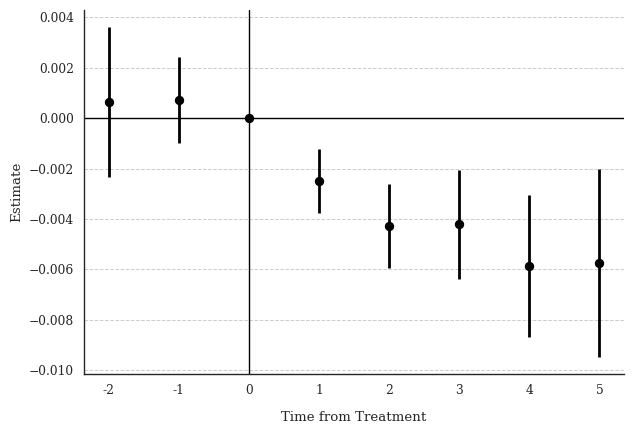

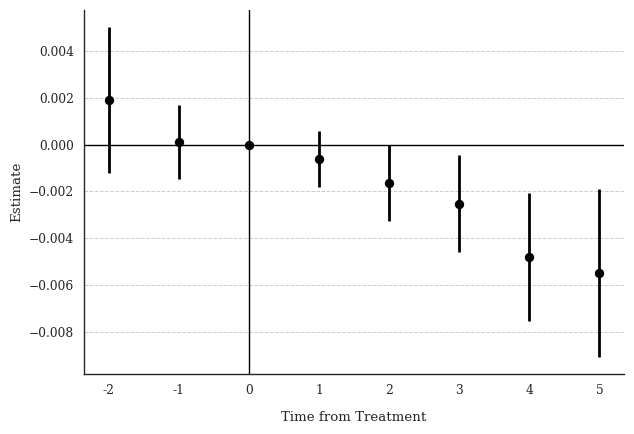

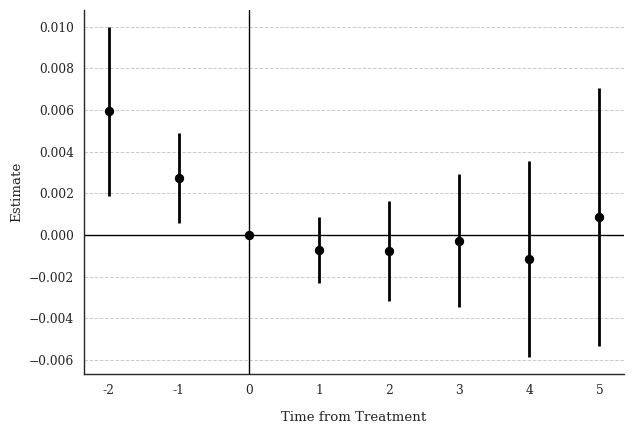

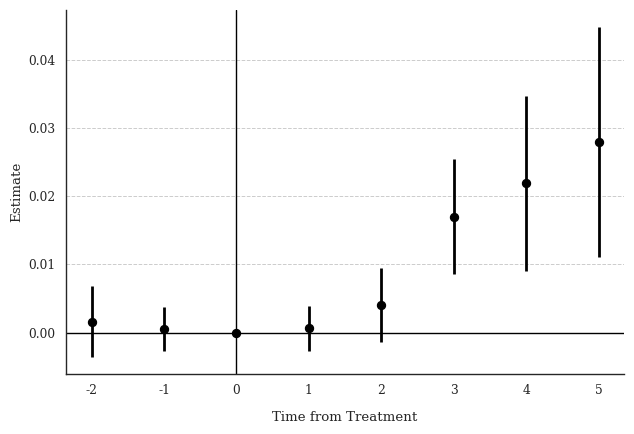

In [25]:
DID(df_rnp_social, 'pres', 1995, 'RN',seuil)
DID(df_rp_social, 'pres', 1995, 'RN',seuil)
DID(df_ui_social, 'pres', 1995, 'RN',seuil)
DID(df_ud_social, 'pres', 1995, 'RN',seuil)

##### 10%

In [26]:
seuil = 1 + 0.1

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002351 0.000626 -0.003578 -0.001124 34094.0     6654.0 34094.0       6654.0
            Effect_2 -0.006359 0.000830 -0.007986 -0.004733 26007.0     6098.0 26007.0       6098.0
            Effect_3 -0.008313 0.001092 -0.010453 -0.006172 19430.0     5559.0 19430.0       5559.0
            Effect_4 -0.012187 0.001443 -0.015015 -0.009360 13392.0     4745.0 13392.0       4745.0
            Effect_5 -0.014577 0.001840 -0.018183 -0.010972  7236.0     3254.0  7236.0       3254.0
Average_Total_Effect -0.007826 0.000880 -0.009551 -0.006101 53761.0    26310.0 53761.0      26310.0
           Placebo_1  0.001390 0.000891 -0.000357  0.003136 23251.0     3352.0 23251.0       3352.0
           Placebo_2  0.000790 0.001583 -0.002311  0.003892  9956.0     1314.0  9956.0       1314.0
Test of joint nullity of the effec

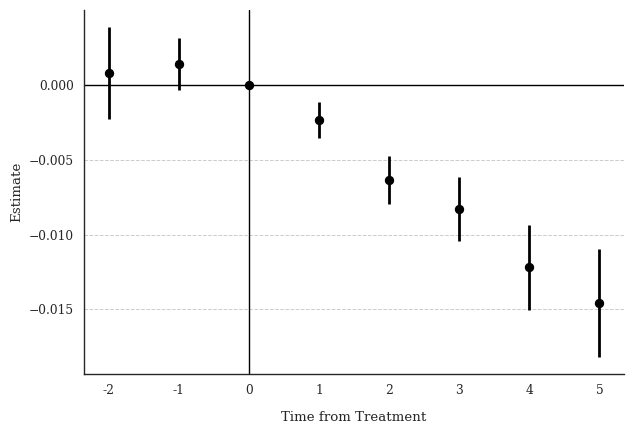

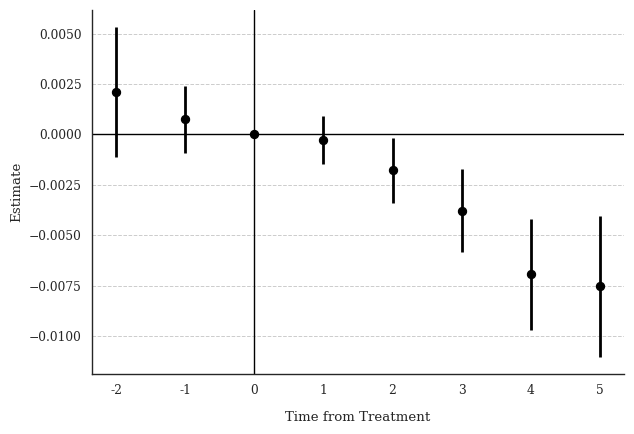

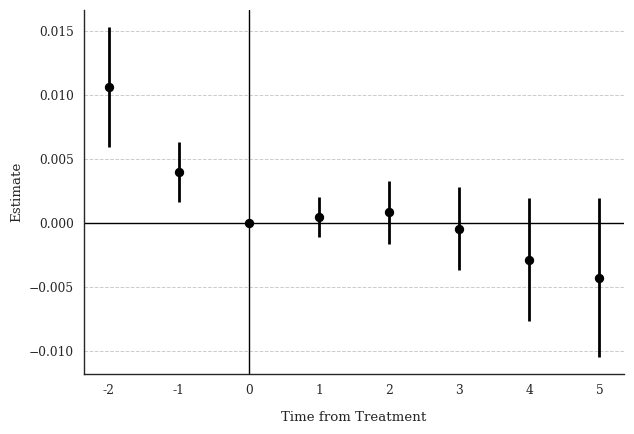

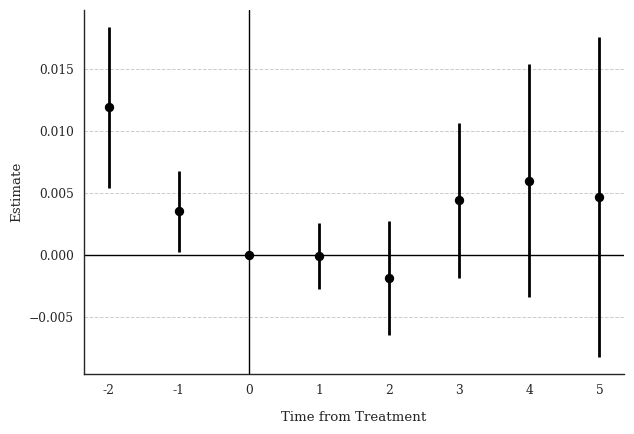

In [27]:
DID(df_rnp_social, 'pres', 1995, 'RN',seuil)
DID(df_rp_social, 'pres', 1995, 'RN',seuil)
DID(df_ui_social, 'pres', 1995, 'RN',seuil)
DID(df_ud_social, 'pres', 1995, 'RN',seuil)

#### Legislatives

In [28]:
seuil = 1 + 0.2

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002534 0.000695 -0.003897 -0.001171 35926.0     5996.0 35926.0       5996.0
            Effect_2 -0.003031 0.000898 -0.004791 -0.001271 27261.0     5413.0 27261.0       5413.0
            Effect_3 -0.003986 0.001141 -0.006224 -0.001749 20110.0     4827.0 20110.0       4827.0
            Effect_4 -0.007408 0.001496 -0.010341 -0.004476 13544.0     3991.0 13544.0       3991.0
            Effect_5 -0.008691 0.002226 -0.013055 -0.004328  6901.0     2477.0  6901.0       2477.0
Average_Total_Effect -0.004490 0.000881 -0.006216 -0.002764 52645.0    22704.0 52645.0      22704.0
           Placebo_1  0.000324 0.000889 -0.001419  0.002067 25314.0     3476.0 25314.0       3476.0
           Placebo_2 -0.003426 0.001491 -0.006349 -0.000504 10933.0     1385.0 10933.0       1385.0
Test of joint nullity of the effec

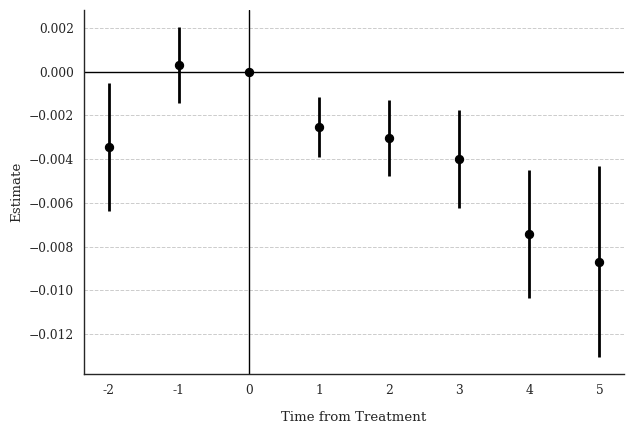

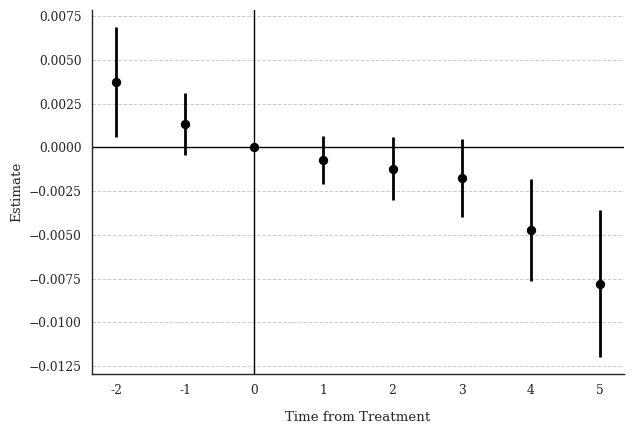

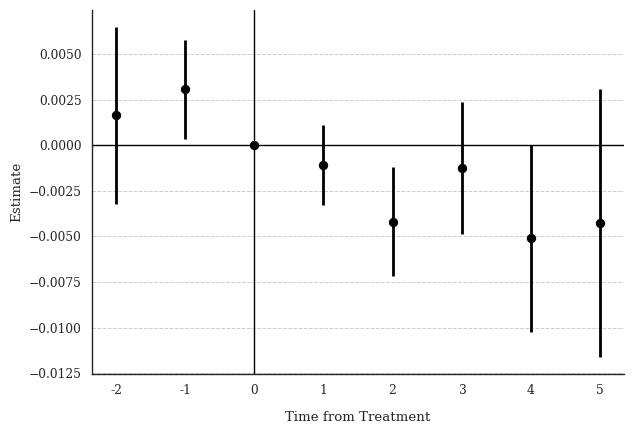

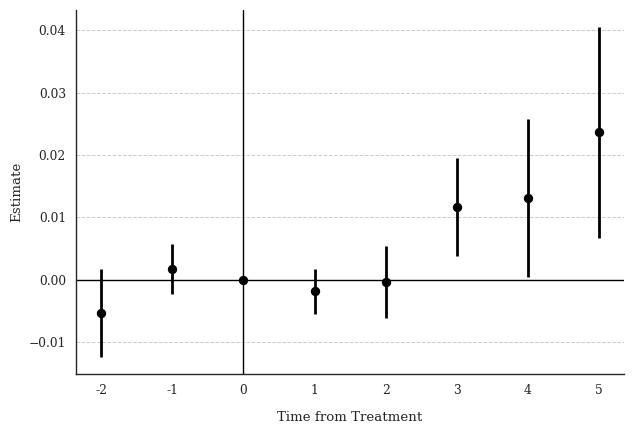

In [29]:
DID(df_rnp_social, 'leg', 1997, 'RN',seuil)
DID(df_rp_social, 'leg', 1997, 'RN',seuil)
DID(df_ui_social, 'leg', 1997, 'RN',seuil)
DID(df_ud_social, 'leg', 1997, 'RN',seuil)

##### 30%

In [30]:
seuil = 1 + 0.3

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002454 0.000718 -0.003862 -0.001046 37705.0     5709.0 37705.0       5709.0
            Effect_2 -0.002599 0.000914 -0.004390 -0.000809 28658.0     5127.0 28658.0       5127.0
            Effect_3 -0.002620 0.001163 -0.004899 -0.000342 21064.0     4521.0 21064.0       4521.0
            Effect_4 -0.004644 0.001513 -0.007608 -0.001679 14075.0     3695.0 14075.0       3695.0
            Effect_5 -0.004328 0.002282 -0.008801  0.000145  7059.0     2221.0  7059.0       2221.0
Average_Total_Effect -0.003100 0.000882 -0.004829 -0.001371 53280.0    21273.0 53280.0      21273.0
           Placebo_1 -0.000166 0.000889 -0.001909  0.001577 26966.0     3445.0 26966.0       3445.0
           Placebo_2 -0.003400 0.001458 -0.006257 -0.000543 11770.0     1395.0 11770.0       1395.0
Test of joint nullity of the effec

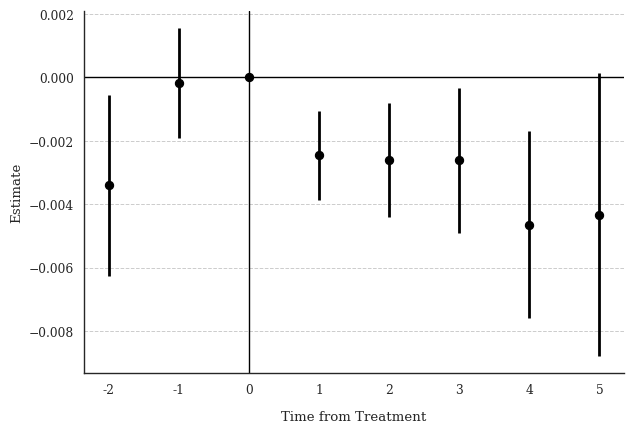

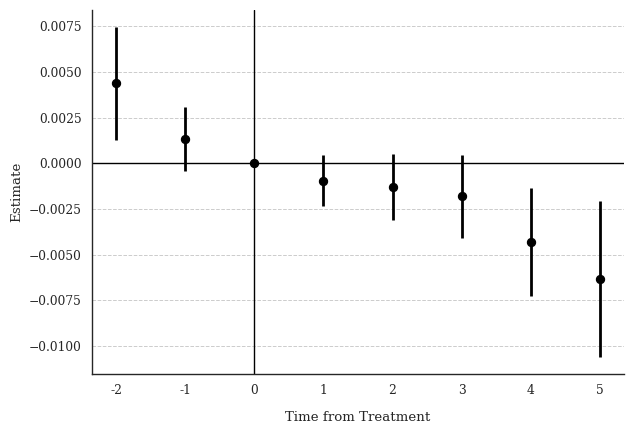

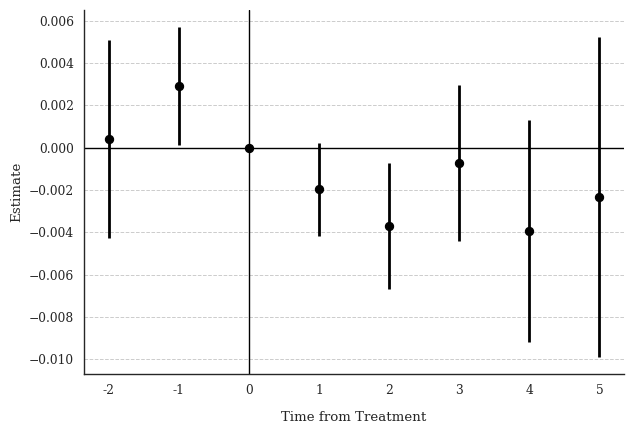

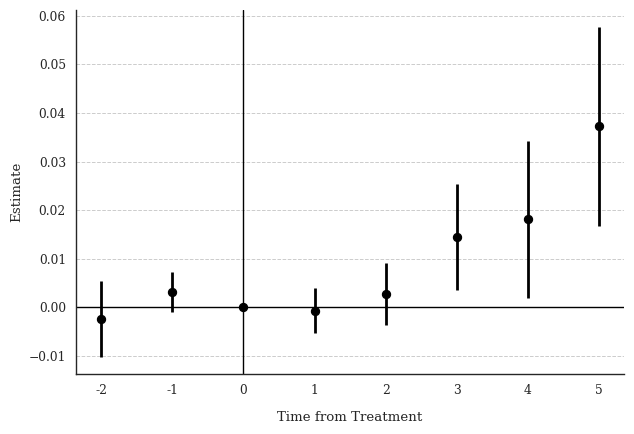

In [31]:
DID(df_rnp_social, 'leg', 1997, 'RN',seuil)
DID(df_rp_social, 'leg', 1997, 'RN',seuil)
DID(df_ui_social, 'leg', 1997, 'RN',seuil)
DID(df_ud_social, 'leg', 1997, 'RN',seuil)

##### 10%

In [32]:
seuil = 1 + 0.1

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002433 0.000690 -0.003786 -0.001080 33664.0     6196.0 33664.0       6196.0
            Effect_2 -0.003080 0.000897 -0.004838 -0.001322 25576.0     5641.0 25576.0       5641.0
            Effect_3 -0.004825 0.001144 -0.007067 -0.002582 18995.0     5101.0 18995.0       5101.0
            Effect_4 -0.010210 0.001502 -0.013154 -0.007266 12953.0     4286.0 12953.0       4286.0
            Effect_5 -0.014364 0.002191 -0.018658 -0.010070  6792.0     2797.0  6792.0       2797.0
Average_Total_Effect -0.005870 0.000898 -0.007631 -0.004109 51500.0    24021.0 51500.0      24021.0
           Placebo_1  0.000314 0.000914 -0.001477  0.002105 23281.0     3356.0 23281.0       3356.0
           Placebo_2 -0.003798 0.001542 -0.006820 -0.000776  9980.0     1318.0  9980.0       1318.0
Test of joint nullity of the effec

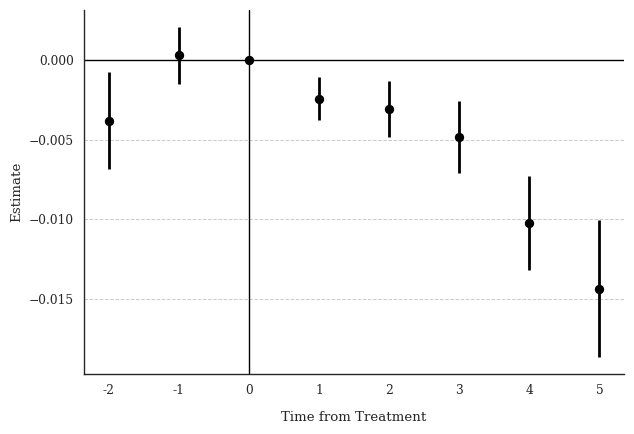

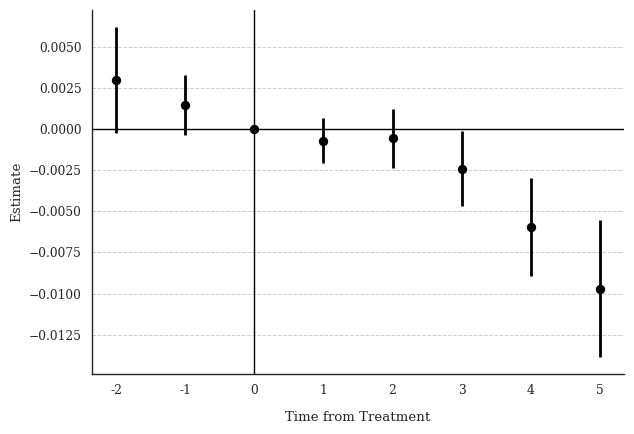

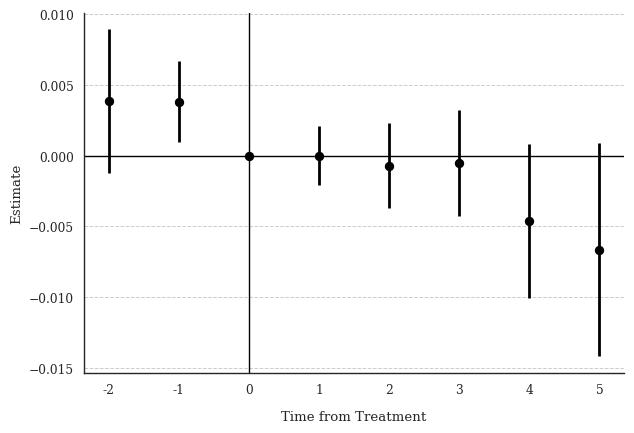

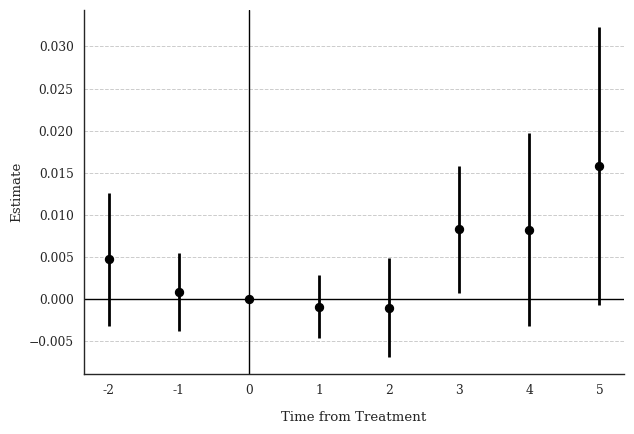

In [33]:
DID(df_rnp_social, 'leg', 1997, 'RN',seuil)
DID(df_rp_social, 'leg', 1997, 'RN',seuil)
DID(df_ui_social, 'leg', 1997, 'RN',seuil)
DID(df_ud_social, 'leg', 1997, 'RN',seuil)

### PS

#### Presidentielles

In [34]:
seuil = 1 + 0.2

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000505 0.000742 -0.000949  0.001960 36233.0     6334.0 36233.0       6334.0
            Effect_2  0.000359 0.000945 -0.001493  0.002210 27569.0     5750.0 27569.0       5750.0
            Effect_3 -0.002828 0.001073 -0.004931 -0.000724 20424.0     5165.0 20424.0       5165.0
            Effect_4 -0.003002 0.001321 -0.005592 -0.000412 13863.0     4330.0 13863.0       4330.0
            Effect_5 -0.005361 0.001811 -0.008910 -0.001813  7225.0     2814.0  7225.0       2814.0
Average_Total_Effect -0.001534 0.000859 -0.003219  0.000150 54304.0    24393.0 54304.0      24393.0
           Placebo_1  0.001795 0.001043 -0.000249  0.003840 25280.0     3472.0 25280.0       3472.0
           Placebo_2  0.000333 0.001714 -0.003027  0.003693 10907.0     1380.0 10907.0       1380.0
Test of joint nullity of the effec

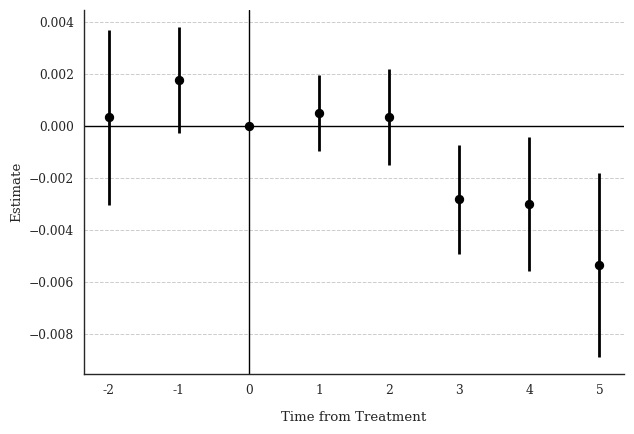

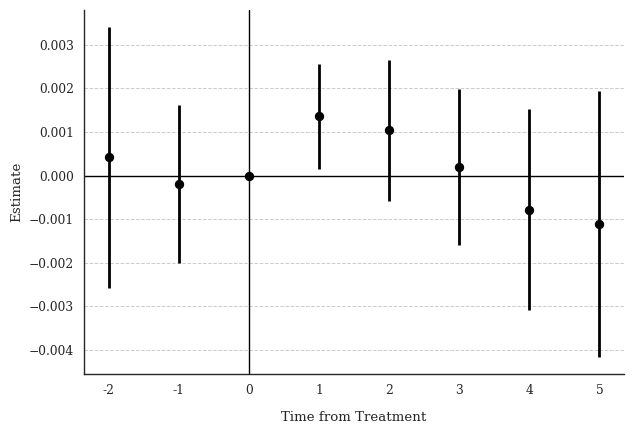

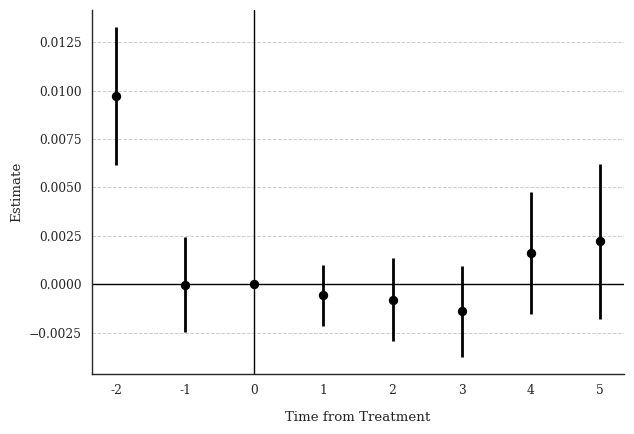

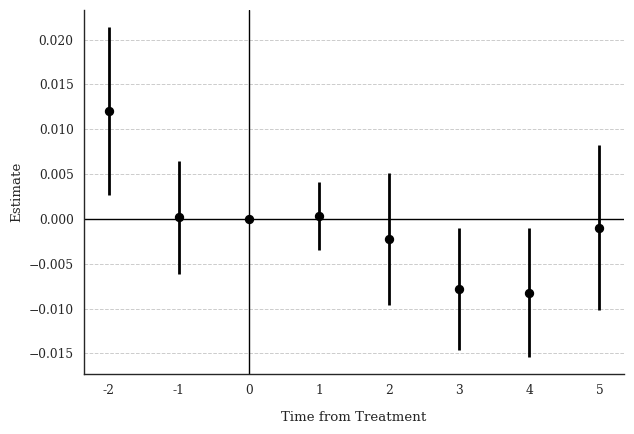

In [35]:
DID(df_rnp_social, 'pres', 1995, 'PS',seuil)
DID(df_rp_social, 'pres', 1995, 'PS',seuil)
DID(df_ui_social, 'pres', 1995, 'PS',seuil)
DID(df_ud_social, 'pres', 1995, 'PS',seuil)

#### Legislatives

In [36]:
seuil = 1 + 0.2

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000671 0.001691 -0.002644 0.003986 35926.0     5996.0 35926.0       5996.0
            Effect_2  0.000729 0.002315 -0.003809 0.005267 27261.0     5413.0 27261.0       5413.0
            Effect_3 -0.005051 0.002760 -0.010460 0.000358 20110.0     4827.0 20110.0       4827.0
            Effect_4 -0.000224 0.002945 -0.005996 0.005547 13544.0     3991.0 13544.0       3991.0
            Effect_5  0.012536 0.003988  0.004719 0.020354  6901.0     2477.0  6901.0       2477.0
Average_Total_Effect  0.000606 0.001915 -0.003147 0.004358 52645.0    22704.0 52645.0      22704.0
           Placebo_1 -0.000572 0.002235 -0.004954 0.003809 25314.0     3476.0 25314.0       3476.0
           Placebo_2 -0.003275 0.004223 -0.011551 0.005001 10933.0     1385.0 10933.0       1385.0
Test of joint nullity of the effects: p-val

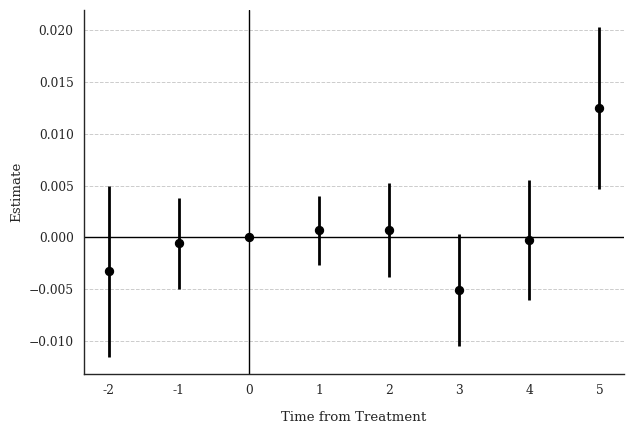

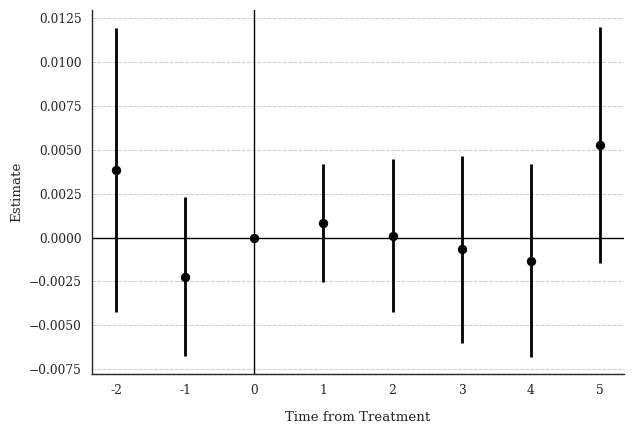

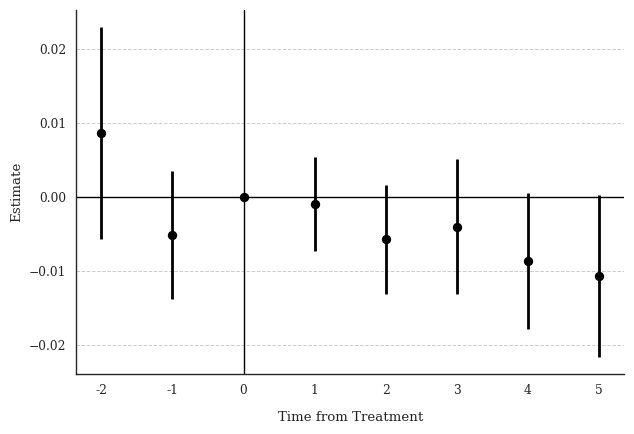

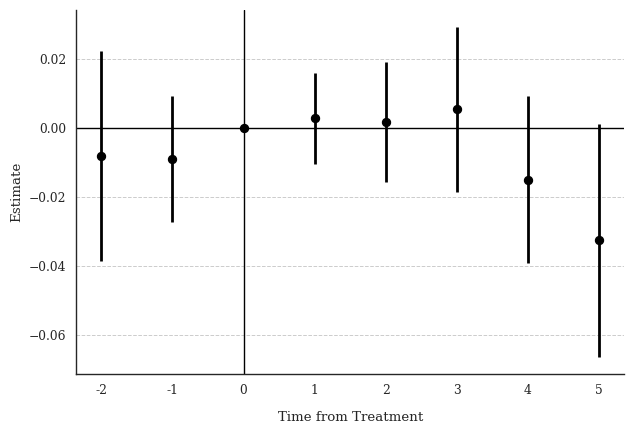

In [37]:
DID(df_rnp_social, 'leg', 1997, 'PS',seuil)
DID(df_rp_social, 'leg', 1997, 'PS',seuil)
DID(df_ui_social, 'leg', 1997, 'PS',seuil)
DID(df_ud_social, 'leg', 1997, 'PS',seuil)

# Transactionnel

## Diminution

### RN

#### Presidentielles

##### 40%

In [38]:
seuil = 1 - 0.4

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.001486 0.000969 -0.003386  0.000414 46717.0     1941.0 46717.0       1941.0
            Effect_2 -0.004724 0.001265 -0.007204 -0.002244 36810.0     1809.0 36810.0       1809.0
            Effect_3 -0.005668 0.001540 -0.008686 -0.002649 27423.0     1622.0 27423.0       1622.0
            Effect_4 -0.009970 0.001994 -0.013877 -0.006063 18236.0     1322.0 18236.0       1322.0
            Effect_5 -0.011646 0.003001 -0.017528 -0.005763  8975.0      747.0  8975.0        747.0
Average_Total_Effect -0.005712 0.001233 -0.008128 -0.003296 52241.0     7441.0 52241.0       7441.0
           Placebo_1  0.003374 0.001246  0.000933  0.005816 36162.0     1185.0 36162.0       1185.0
           Placebo_2  0.000023 0.002159 -0.004208  0.004254 17386.0      484.0 17386.0        484.0
Test of joint nullity of the effec

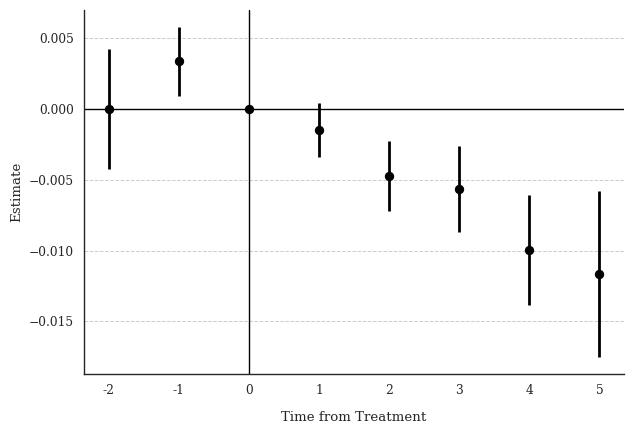

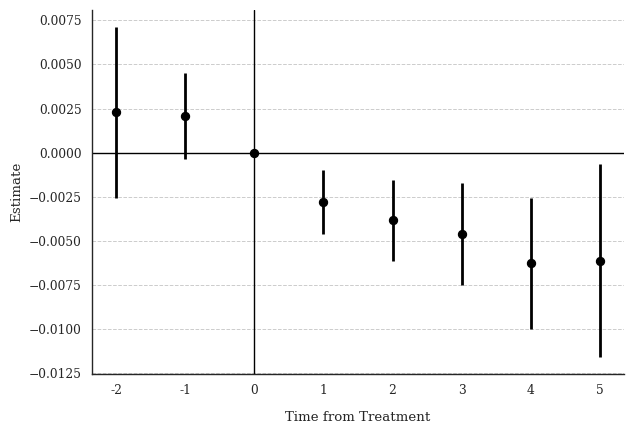

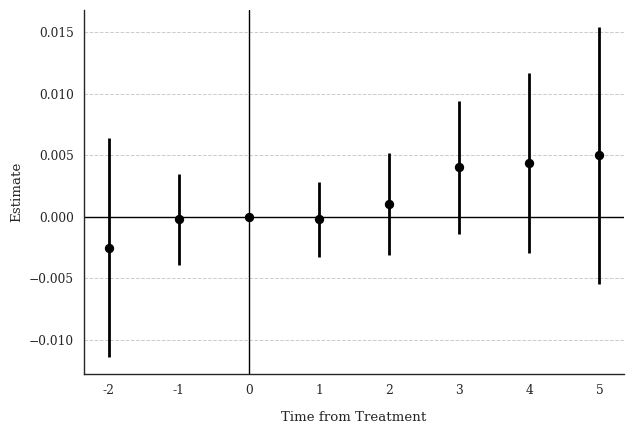

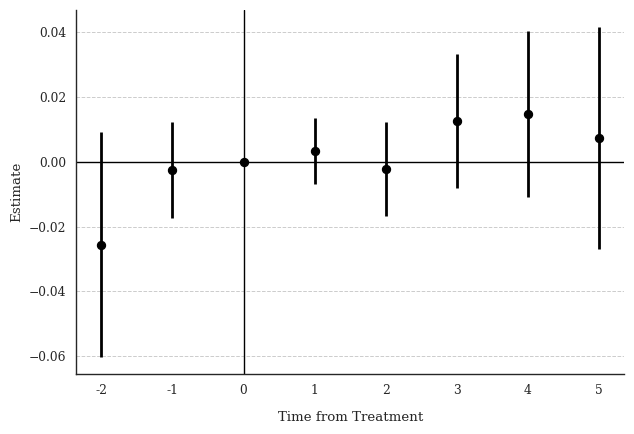

In [39]:
DID(df_rnp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_rp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ui_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ud_transactionnel, 'pres', 1995, 'RN',seuil)

##### 30%

In [40]:
seuil = 1 - 0.3

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002241 0.000921 -0.004047 -0.000435 44621.0     2085.0 44621.0       2085.0
            Effect_2 -0.005995 0.001199 -0.008345 -0.003646 35146.0     1962.0 35146.0       1962.0
            Effect_3 -0.007369 0.001462 -0.010235 -0.004504 26233.0     1791.0 26233.0       1791.0
            Effect_4 -0.011867 0.001885 -0.015562 -0.008171 17507.0     1486.0 17507.0       1486.0
            Effect_5 -0.014257 0.002765 -0.019676 -0.008837  8660.0      874.0  8660.0        874.0
Average_Total_Effect -0.007286 0.001185 -0.009607 -0.004964 50756.0     8198.0 50756.0       8198.0
           Placebo_1  0.003423 0.001216  0.001039  0.005807 34364.0     1202.0 34364.0       1202.0
           Placebo_2 -0.000615 0.002190 -0.004908  0.003677 16485.0      475.0 16485.0        475.0
Test of joint nullity of the effec

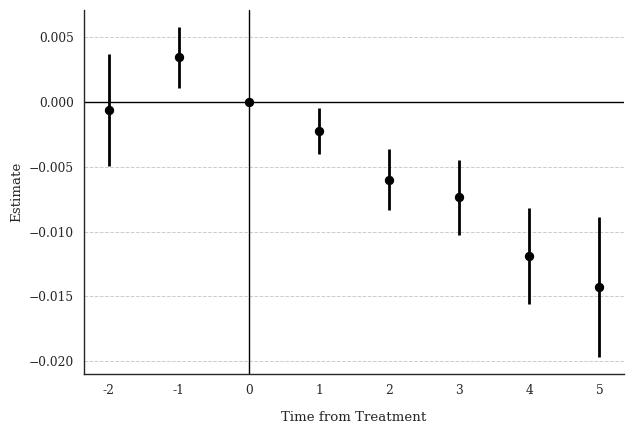

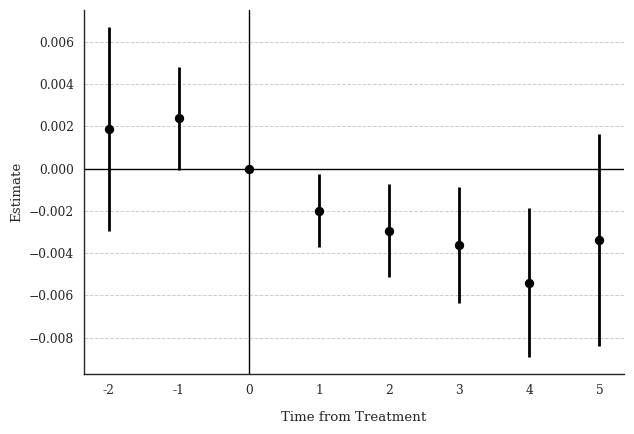

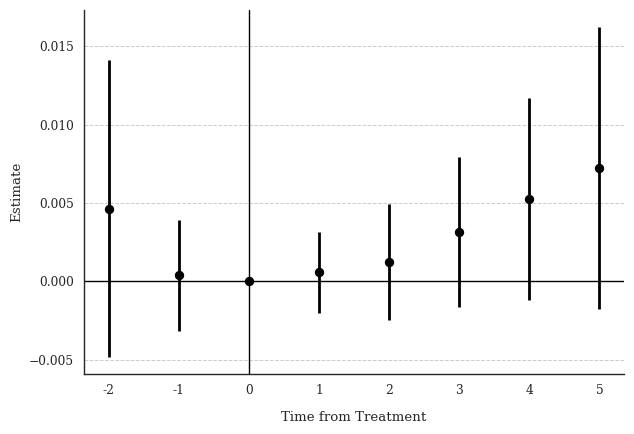

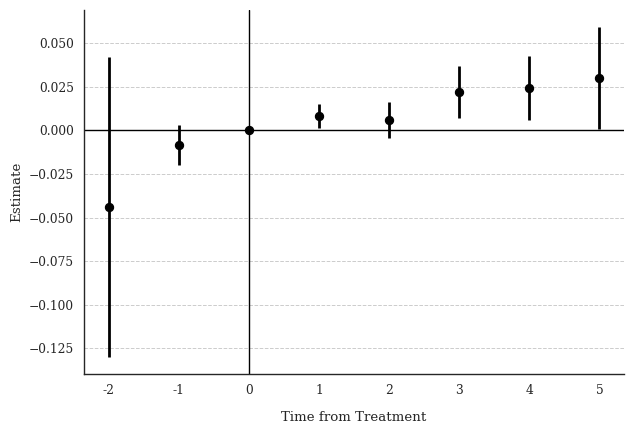

In [41]:
DID(df_rnp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_rp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ui_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ud_transactionnel, 'pres', 1995, 'RN',seuil)

##### 50%

In [42]:
seuil = 1 - 0.5

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002048 0.001083 -0.004170  0.000074 49560.0     1630.0 49560.0       1630.0
            Effect_2 -0.004588 0.001403 -0.007337 -0.001838 39098.0     1497.0 39098.0       1497.0
            Effect_3 -0.006321 0.001736 -0.009722 -0.002919 29062.0     1294.0 29062.0       1294.0
            Effect_4 -0.009331 0.002250 -0.013740 -0.004922 19246.0     1030.0 19246.0       1030.0
            Effect_5 -0.013994 0.003597 -0.021045 -0.006943  9416.0      537.0  9416.0        537.0
Average_Total_Effect -0.005930 0.001362 -0.008599 -0.003262 53943.0     5988.0 53943.0       5988.0
           Placebo_1  0.002136 0.001327 -0.000464  0.004737 38664.0     1087.0 38664.0       1087.0
           Placebo_2  0.001001 0.002282 -0.003472  0.005474 18667.0      465.0 18667.0        465.0
Test of joint nullity of the effec

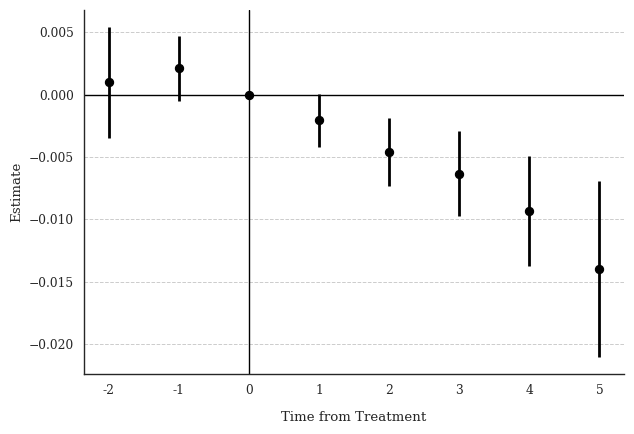

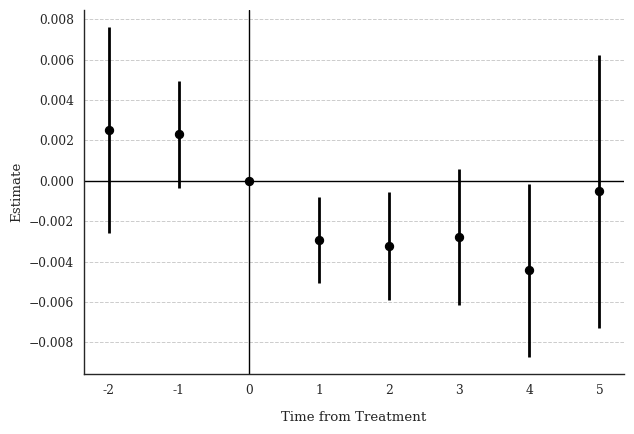

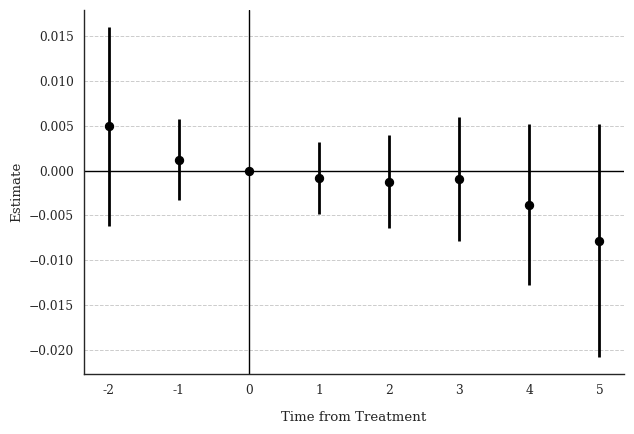

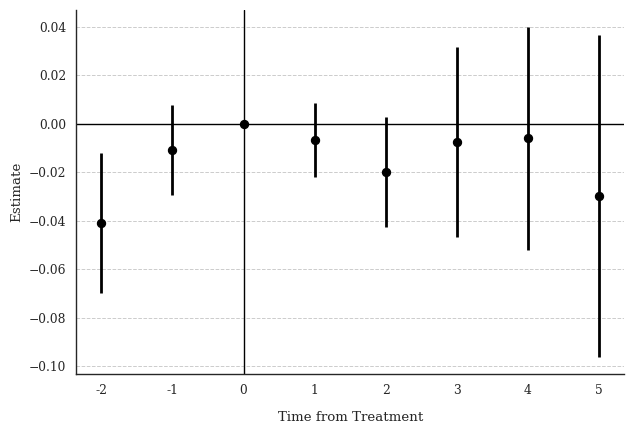

In [43]:
DID(df_rnp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_rp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ui_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ud_transactionnel, 'pres', 1995, 'RN',seuil)

#### Legislatives

In [44]:
seuil = 1 - 0.4

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.001411 0.001057 -0.003484  0.000661 46712.0     1901.0 46712.0       1901.0
            Effect_2 -0.001137 0.001358 -0.003800  0.001525 36805.0     1768.0 36805.0       1768.0
            Effect_3 -0.004232 0.001659 -0.007483 -0.000981 27412.0     1581.0 27412.0       1581.0
            Effect_4 -0.007107 0.002130 -0.011282 -0.002932 18226.0     1283.0 18226.0       1283.0
            Effect_5 -0.014447 0.003310 -0.020935 -0.007958  8961.0      707.0  8961.0        707.0
Average_Total_Effect -0.004243 0.001216 -0.006627 -0.001859 52070.0     7240.0 52070.0       7240.0
           Placebo_1  0.002933 0.001250  0.000483  0.005384 36202.0     1184.0 36202.0       1184.0
           Placebo_2 -0.002010 0.002107 -0.006138  0.002119 17419.0      485.0 17419.0        485.0
Test of joint nullity of the effec

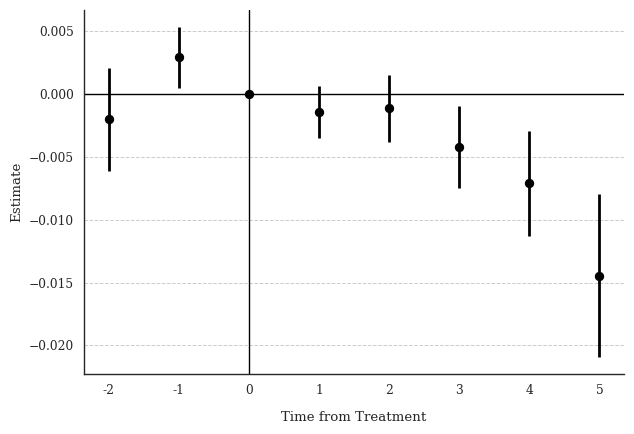

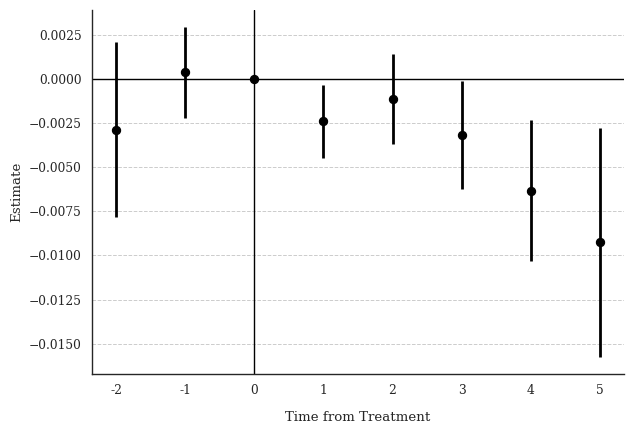

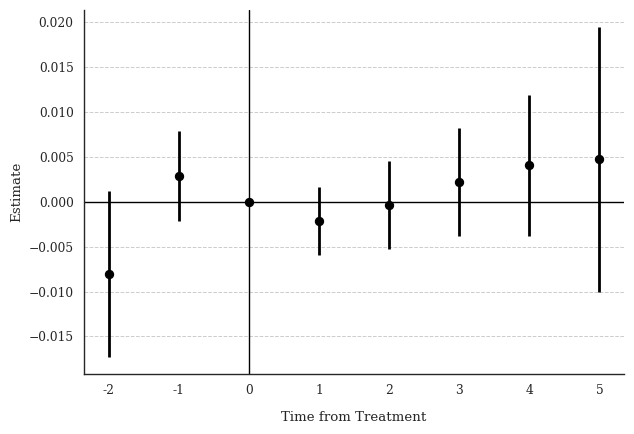

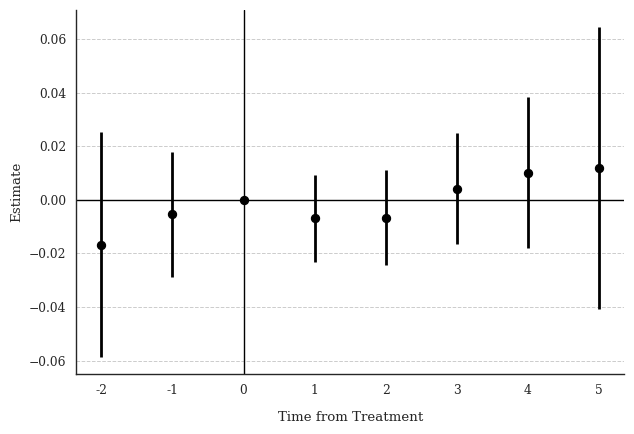

In [45]:
DID(df_rnp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_rp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ui_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ud_transactionnel, 'leg', 1997, 'RN',seuil)

##### 30%

In [46]:
seuil = 1 - 0.3

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.001561 0.001012 -0.003545  0.000423 44583.0     2015.0 44583.0       2015.0
            Effect_2 -0.001120 0.001293 -0.003654  0.001415 35109.0     1891.0 35109.0       1891.0
            Effect_3 -0.004788 0.001572 -0.007870 -0.001706 26191.0     1719.0 26191.0       1719.0
            Effect_4 -0.007367 0.002023 -0.011331 -0.003403 17465.0     1415.0 17465.0       1415.0
            Effect_5 -0.015130 0.003109 -0.021223 -0.009038  8615.0      803.0  8615.0        803.0
Average_Total_Effect -0.004599 0.001175 -0.006901 -0.002297 50430.0     7843.0 50430.0       7843.0
           Placebo_1  0.002759 0.001230  0.000349  0.005170 34401.0     1202.0 34401.0       1202.0
           Placebo_2 -0.002653 0.002150 -0.006866  0.001561 16517.0      476.0 16517.0        476.0
Test of joint nullity of the effec

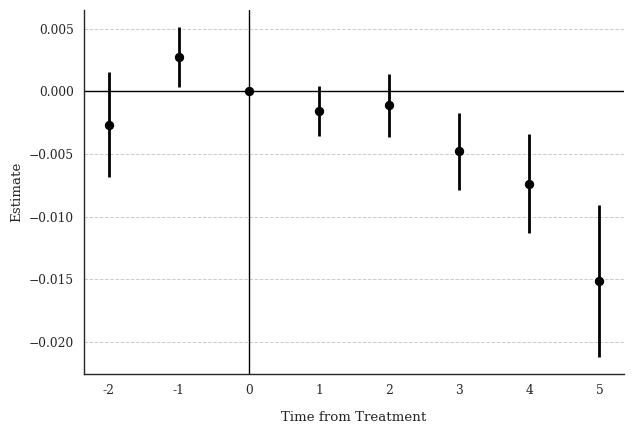

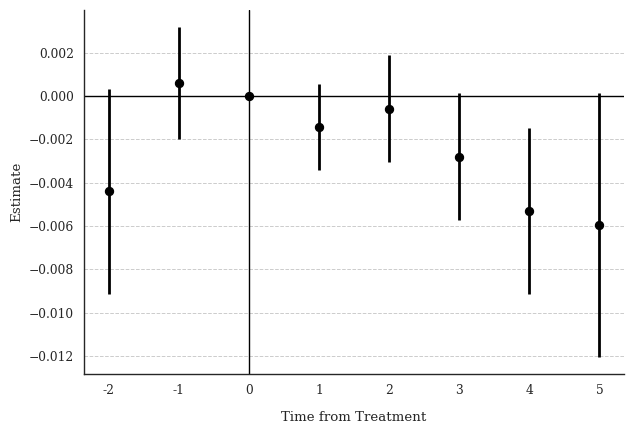

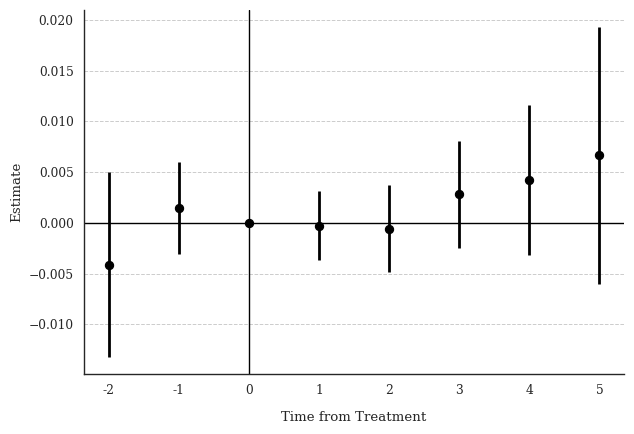

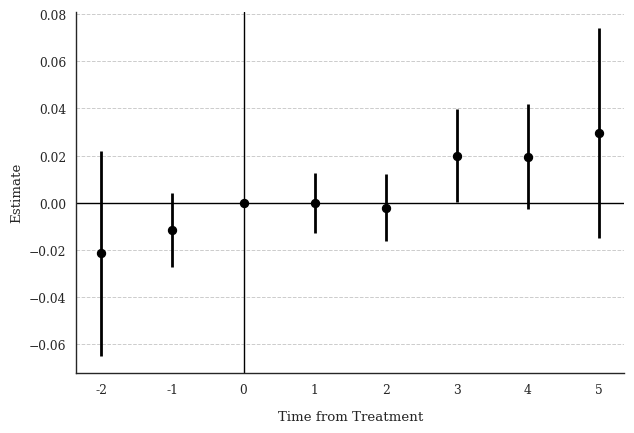

In [47]:
DID(df_rnp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_rp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ui_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ud_transactionnel, 'leg', 1997, 'RN',seuil)

##### 50%

In [48]:
seuil = 1 - 0.5

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002054 0.001186 -0.004379  0.000271 49572.0     1607.0 49572.0       1607.0
            Effect_2 -0.002116 0.001529 -0.005112  0.000881 39111.0     1473.0 39111.0       1473.0
            Effect_3 -0.006080 0.001867 -0.009739 -0.002421 29070.0     1271.0 29070.0       1271.0
            Effect_4 -0.007677 0.002407 -0.012394 -0.002961 19251.0     1007.0 19251.0       1007.0
            Effect_5 -0.013525 0.003873 -0.021115 -0.005934  9418.0      514.0  9418.0        514.0
Average_Total_Effect -0.004909 0.001339 -0.007533 -0.002285 53857.0     5872.0 53857.0       5872.0
           Placebo_1  0.002987 0.001325  0.000391  0.005584 38704.0     1085.0 38704.0       1085.0
           Placebo_2 -0.003148 0.002118 -0.007299  0.001002 18700.0      466.0 18700.0        466.0
Test of joint nullity of the effec

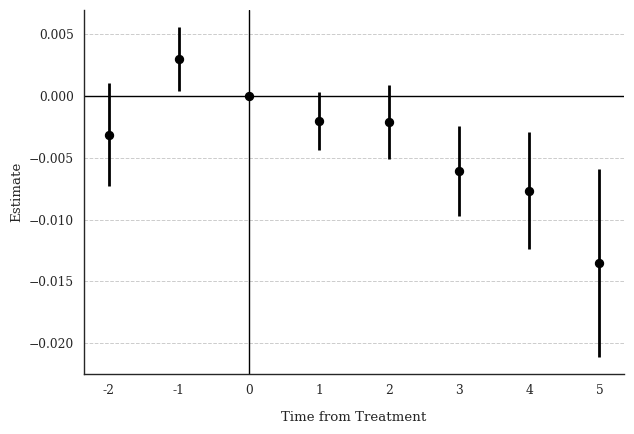

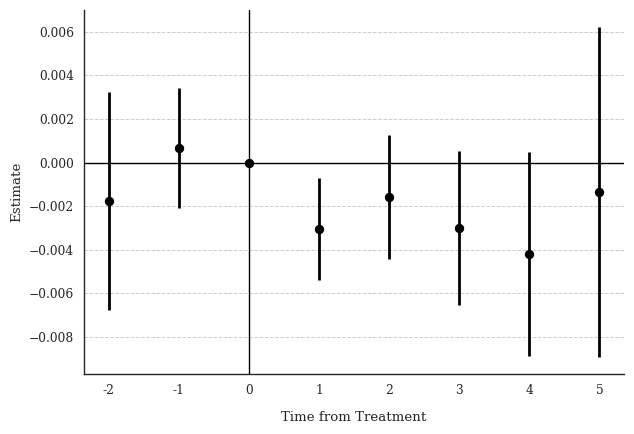

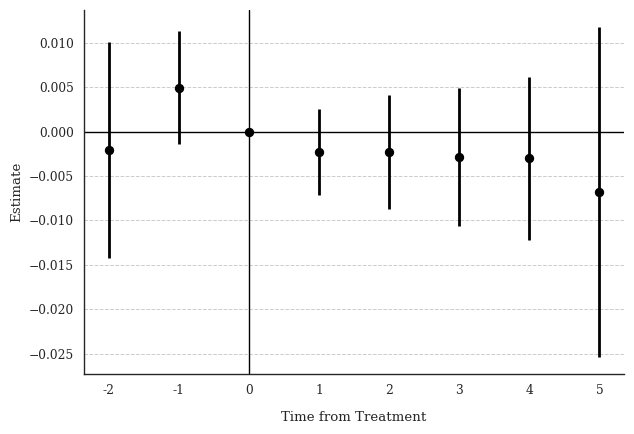

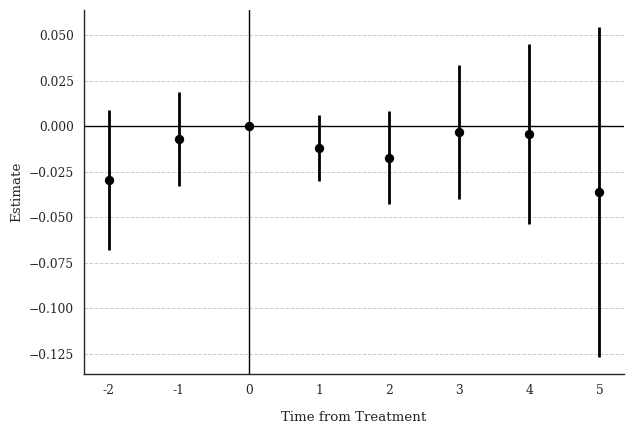

In [49]:
DID(df_rnp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_rp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ui_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ud_transactionnel, 'leg', 1997, 'RN',seuil)

### PS

#### Presidentielles

In [50]:
seuil = 1 - 0.4

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000267 0.001171 -0.002028 0.002562 46717.0     1941.0 46717.0       1941.0
            Effect_2 -0.000834 0.001427 -0.003630 0.001962 36810.0     1809.0 36810.0       1809.0
            Effect_3  0.000057 0.001573 -0.003026 0.003141 27423.0     1622.0 27423.0       1622.0
            Effect_4  0.002878 0.001921 -0.000886 0.006642 18236.0     1322.0 18236.0       1322.0
            Effect_5  0.005088 0.003066 -0.000921 0.011096  8975.0      747.0  8975.0        747.0
Average_Total_Effect  0.000901 0.001230 -0.001509 0.003312 52241.0     7441.0 52241.0       7441.0
           Placebo_1 -0.000273 0.001463 -0.003140 0.002595 36162.0     1185.0 36162.0       1185.0
           Placebo_2 -0.003745 0.002538 -0.008720 0.001230 17386.0      484.0 17386.0        484.0
Test of joint nullity of the effects: p-val

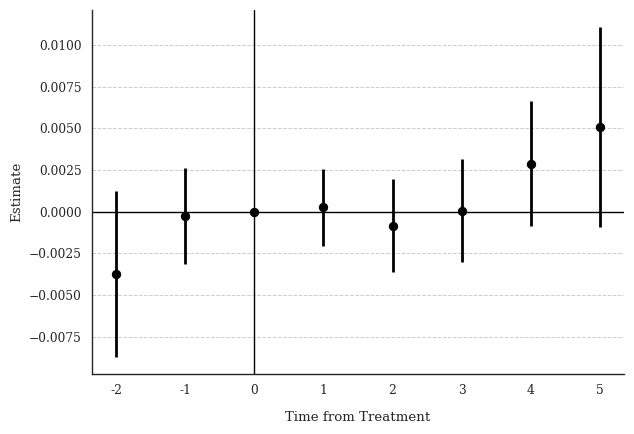

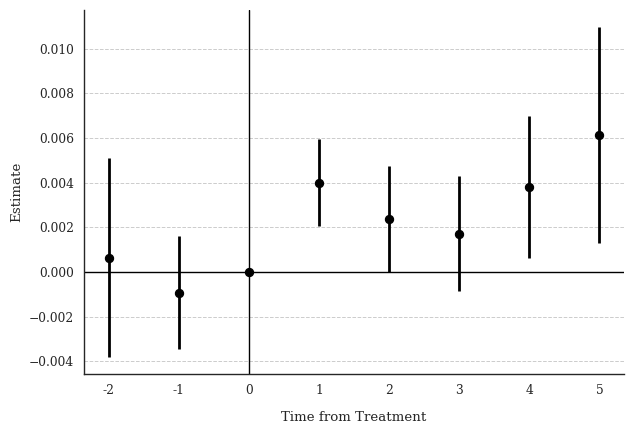

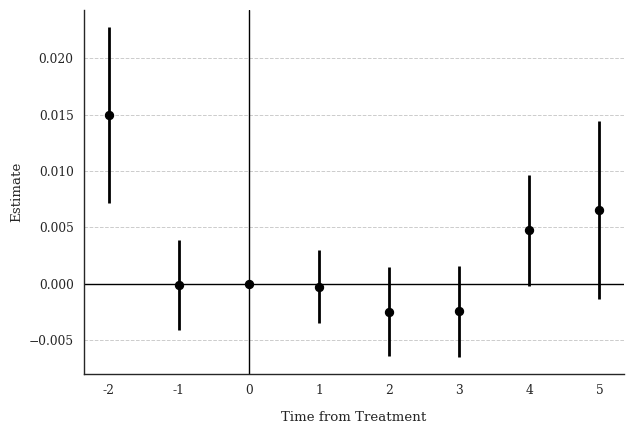

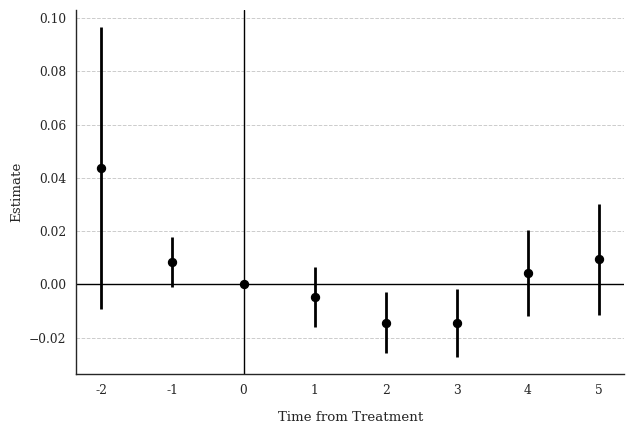

In [51]:
DID(df_rnp_transactionnel, 'pres', 1995, 'PS',seuil)
DID(df_rp_transactionnel, 'pres', 1995, 'PS',seuil)
DID(df_ui_transactionnel, 'pres', 1995, 'PS',seuil)
DID(df_ud_transactionnel, 'pres', 1995, 'PS',seuil)

#### Legislatives

In [52]:
seuil = 1 - 0.4

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.004679 0.002802 -0.000814 0.010171 46712.0     1901.0 46712.0       1901.0
            Effect_2  0.008576 0.003617  0.001487 0.015665 36805.0     1768.0 36805.0       1768.0
            Effect_3 -0.000961 0.004065 -0.008928 0.007007 27412.0     1581.0 27412.0       1581.0
            Effect_4  0.006610 0.004256 -0.001731 0.014951 18226.0     1283.0 18226.0       1283.0
            Effect_5  0.003970 0.006377 -0.008528 0.016468  8961.0      707.0  8961.0        707.0
Average_Total_Effect  0.004672 0.002797 -0.000811 0.010155 52070.0     7240.0 52070.0       7240.0
           Placebo_1  0.006759 0.003616 -0.000328 0.013845 36202.0     1184.0 36202.0       1184.0
           Placebo_2  0.000696 0.006712 -0.012459 0.013851 17419.0      485.0 17419.0        485.0
Test of joint nullity of the effects: p-val

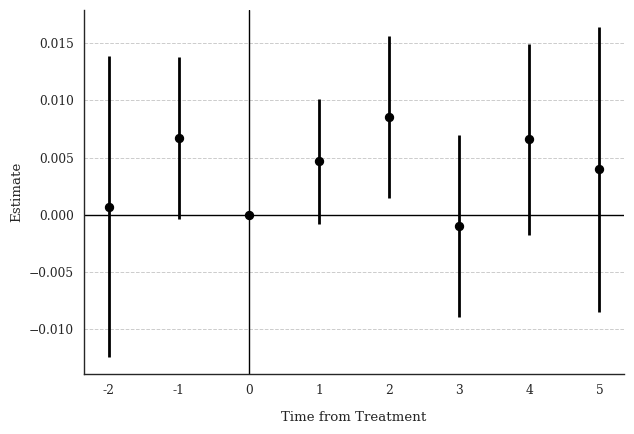

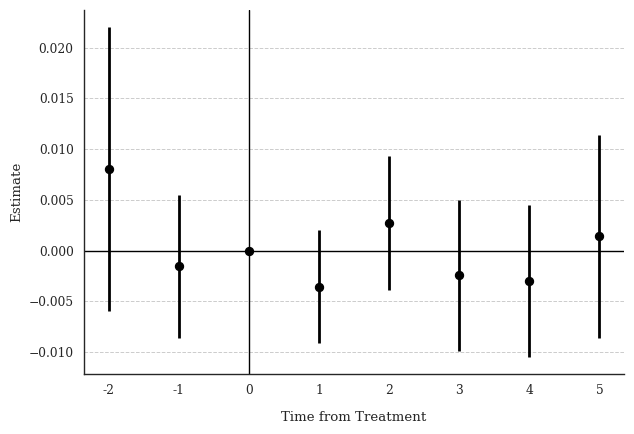

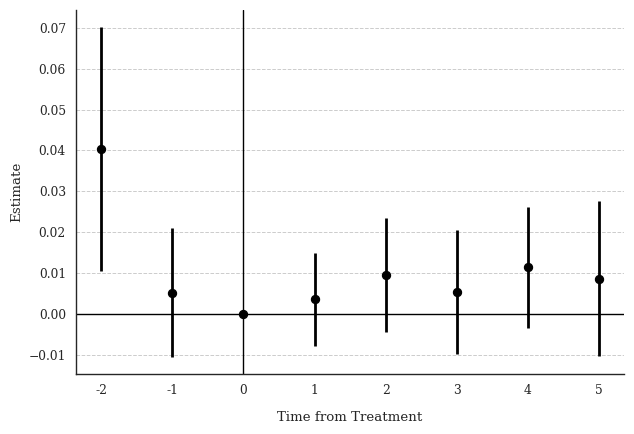

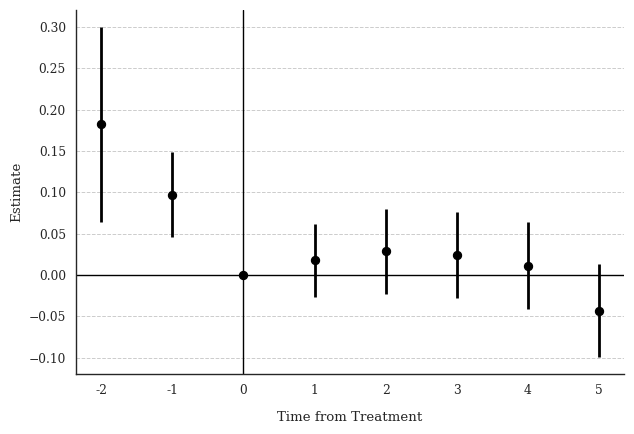

In [53]:
DID(df_rnp_transactionnel, 'leg', 1997, 'PS',seuil)
DID(df_rp_transactionnel, 'leg', 1997, 'PS',seuil)
DID(df_ui_transactionnel, 'leg', 1997, 'PS',seuil)
DID(df_ud_transactionnel, 'leg', 1997, 'PS',seuil)

## Augmentation

### RN

#### Presidentielles

##### 20%

In [54]:
seuil = 1 + 0.2

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000846 0.000605 -0.002032  0.000340 36289.0     9007.0 36289.0       9007.0
            Effect_2 -0.002323 0.000904 -0.004096 -0.000551 25507.0     7304.0 25507.0       7304.0
            Effect_3 -0.004424 0.001268 -0.006910 -0.001938 16296.0     5697.0 16296.0       5697.0
            Effect_4 -0.009100 0.001735 -0.012500 -0.005700  8710.0     3289.0  8710.0       3289.0
            Effect_5 -0.012297 0.002506 -0.017207 -0.007386  3736.0     1875.0  3736.0       1875.0
Average_Total_Effect -0.003783 0.000889 -0.005525 -0.002041 54467.0    27172.0 54467.0      27172.0
           Placebo_1 -0.000083 0.000707 -0.001470  0.001303 25293.0     7103.0 25293.0       7103.0
           Placebo_2 -0.001424 0.001196 -0.003768  0.000920  9355.0     3940.0  9355.0       3940.0
Test of joint nullity of the effec

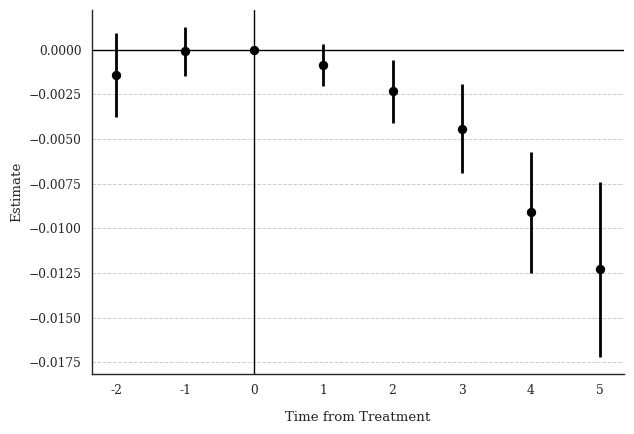

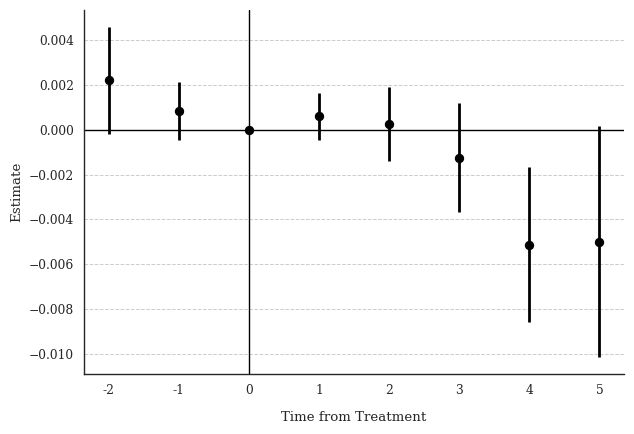

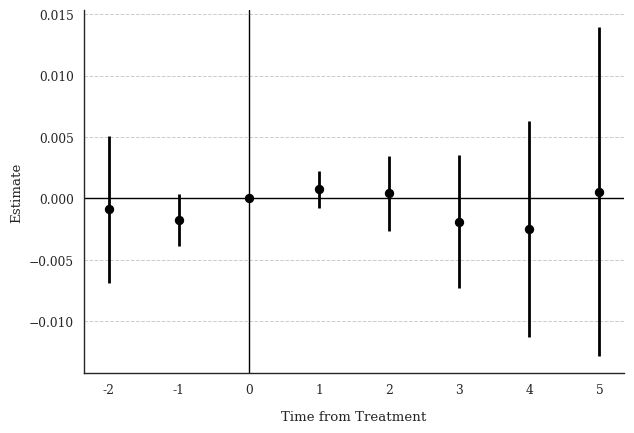

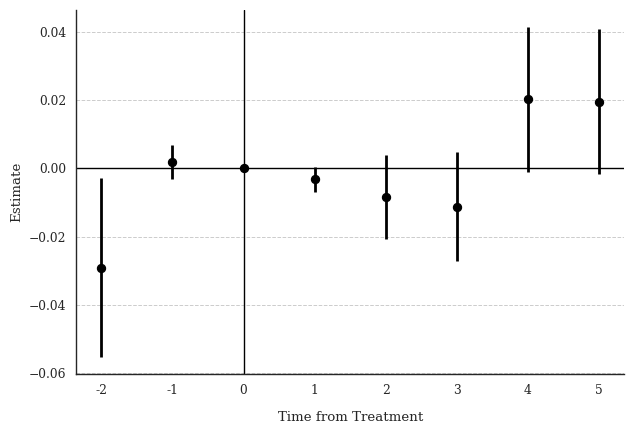

In [55]:
DID(df_rnp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_rp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ui_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ud_transactionnel, 'pres', 1995, 'RN',seuil)

##### 30%

In [56]:
seuil = 1 + 0.3

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000868 0.000604 -0.002052  0.000316 36945.0     8984.0 36945.0       8984.0
            Effect_2 -0.001982 0.000906 -0.003758 -0.000207 25933.0     7249.0 25933.0       7249.0
            Effect_3 -0.003833 0.001271 -0.006324 -0.001342 16506.0     5600.0 16506.0       5600.0
            Effect_4 -0.008165 0.001744 -0.011582 -0.004747  8748.0     3160.0  8748.0       3160.0
            Effect_5 -0.011801 0.002520 -0.016740 -0.006863  3651.0     1722.0  3651.0       1722.0
Average_Total_Effect -0.003360 0.000880 -0.005084 -0.001636 54690.0    26715.0 54690.0      26715.0
           Placebo_1 -0.000152 0.000695 -0.001514  0.001210 25904.0     7233.0 25904.0       7233.0
           Placebo_2 -0.001316 0.001178 -0.003624  0.000992  9596.0     4015.0  9596.0       4015.0
Test of joint nullity of the effec

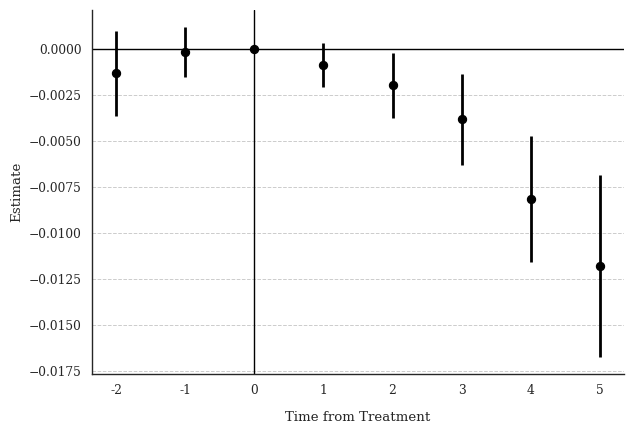

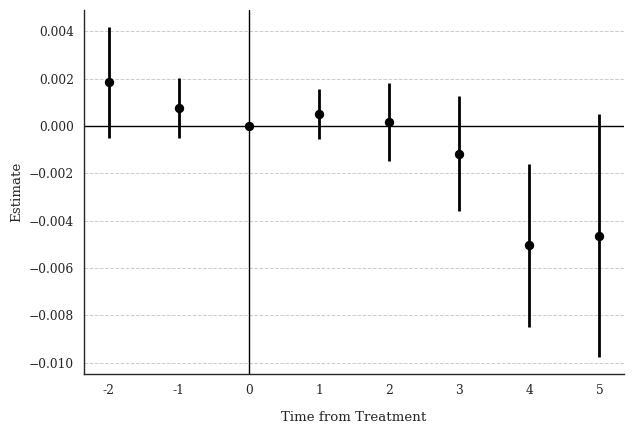

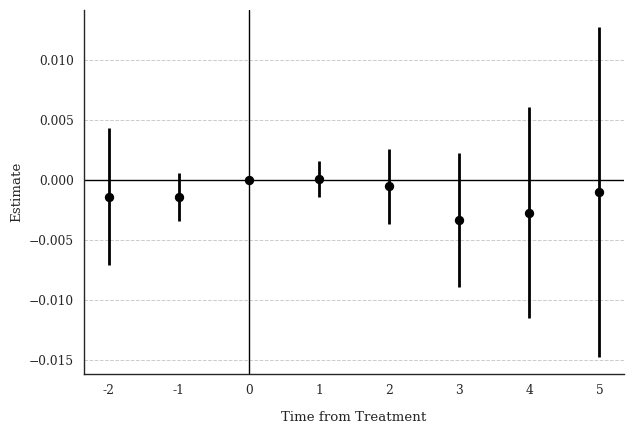

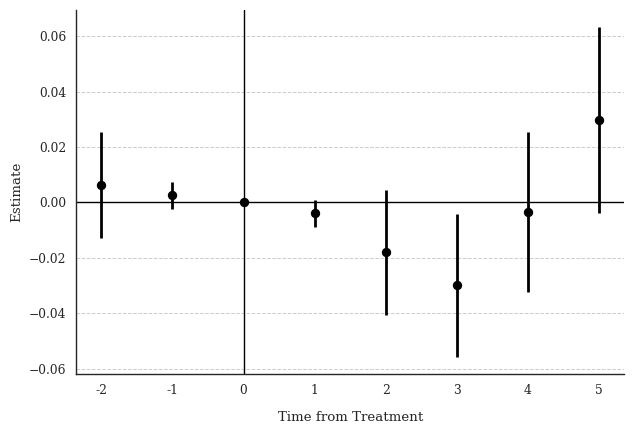

In [57]:
DID(df_rnp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_rp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ui_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ud_transactionnel, 'pres', 1995, 'RN',seuil)

##### 10%

In [58]:
seuil = 1 + 0.1

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000811 0.000609 -0.002005  0.000382 35610.0     8998.0 35610.0       8998.0
            Effect_2 -0.002510 0.000906 -0.004285 -0.000735 25061.0     7306.0 25061.0       7306.0
            Effect_3 -0.004874 0.001271 -0.007365 -0.002384 16066.0     5738.0 16066.0       5738.0
            Effect_4 -0.009562 0.001735 -0.012963 -0.006161  8657.0     3387.0  8657.0       3387.0
            Effect_5 -0.012466 0.002512 -0.017389 -0.007543  3809.0     2018.0  3809.0       2018.0
Average_Total_Effect -0.004050 0.000900 -0.005814 -0.002285 54072.0    27447.0 54072.0      27447.0
           Placebo_1  0.000022 0.000723 -0.001396  0.001440 24693.0     6951.0 24693.0       6951.0
           Placebo_2 -0.001614 0.001222 -0.004008  0.000780  9108.0     3844.0  9108.0       3844.0
Test of joint nullity of the effec

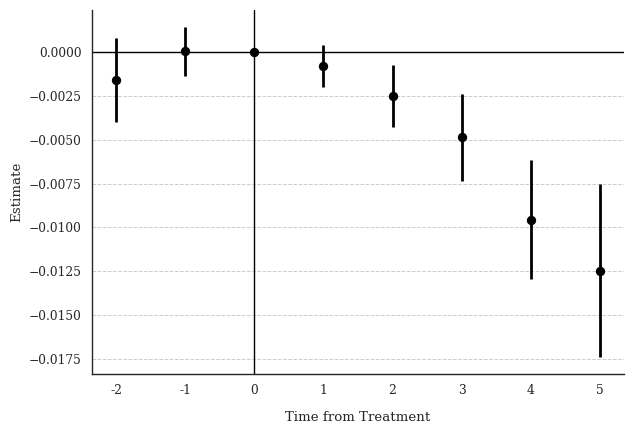

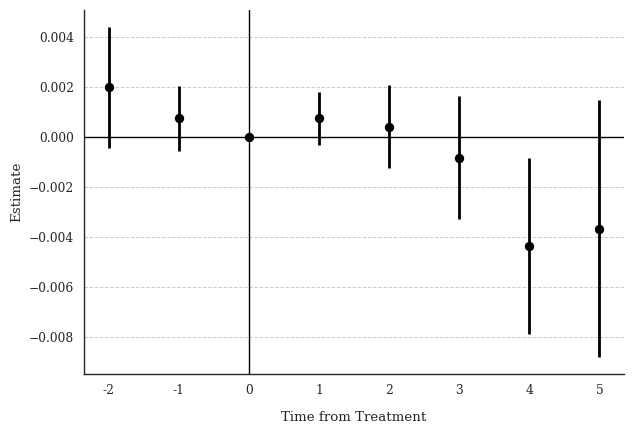

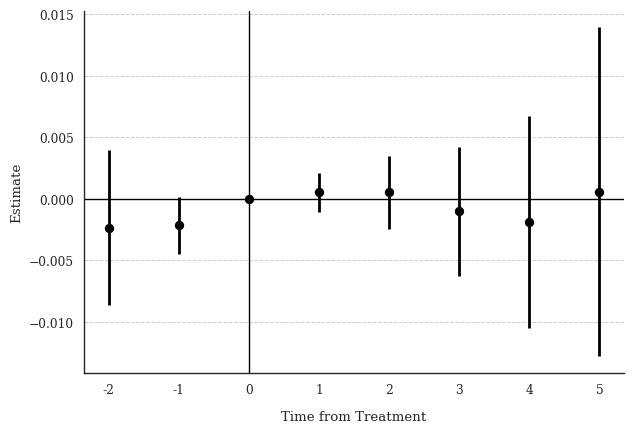

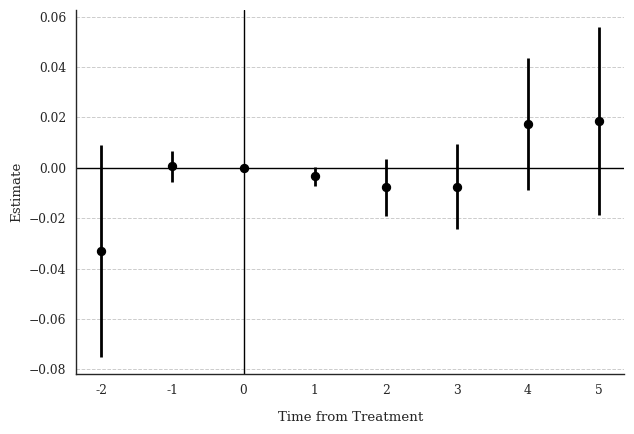

In [59]:
DID(df_rnp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_rp_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ui_transactionnel, 'pres', 1995, 'RN',seuil)
DID(df_ud_transactionnel, 'pres', 1995, 'RN',seuil)

#### Legislatives

In [60]:
seuil = 1 + 0.2

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000208 0.000732 -0.001644  0.001228 36158.0     8856.0 36158.0       8856.0
            Effect_2  0.000663 0.001060 -0.001414  0.002741 25385.0     7155.0 25385.0       7155.0
            Effect_3 -0.000019 0.001510 -0.002978  0.002941 16155.0     5545.0 16155.0       5545.0
            Effect_4 -0.007366 0.001858 -0.011008 -0.003725  8558.0     3136.0  8558.0       3136.0
            Effect_5 -0.012908 0.002915 -0.018621 -0.007195  3571.0     1721.0  3571.0       1721.0
Average_Total_Effect -0.001610 0.001004 -0.003577  0.000358 53729.0    26413.0 53729.0      26413.0
           Placebo_1 -0.000722 0.000776 -0.002242  0.000798 25318.0     7102.0 25318.0       7102.0
           Placebo_2 -0.001240 0.001175 -0.003544  0.001063  9375.0     3957.0  9375.0       3957.0
Test of joint nullity of the effec

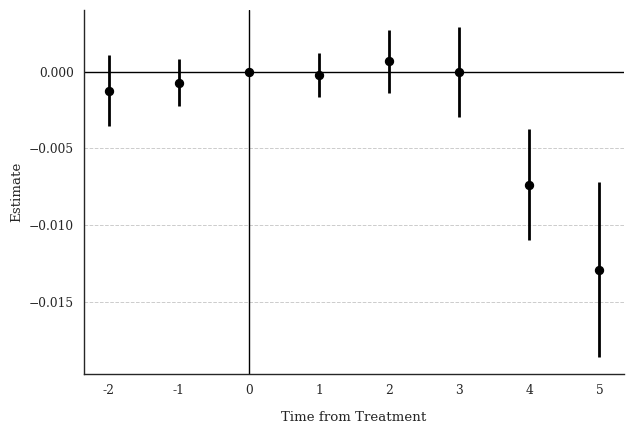

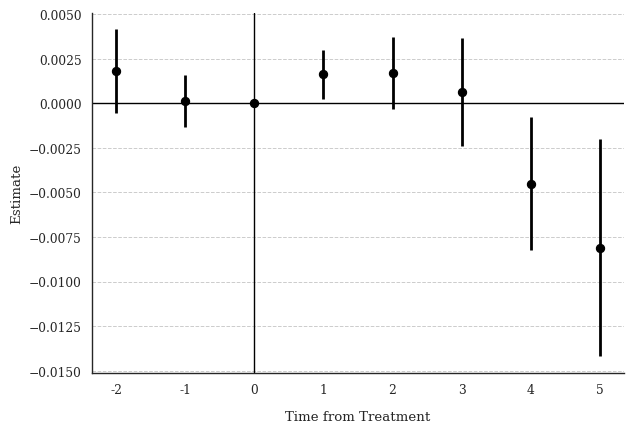

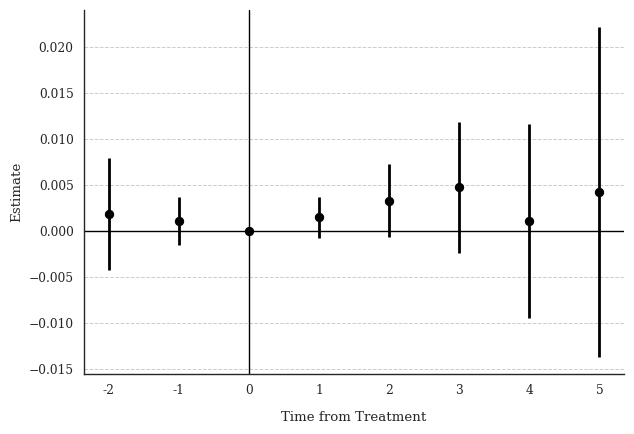

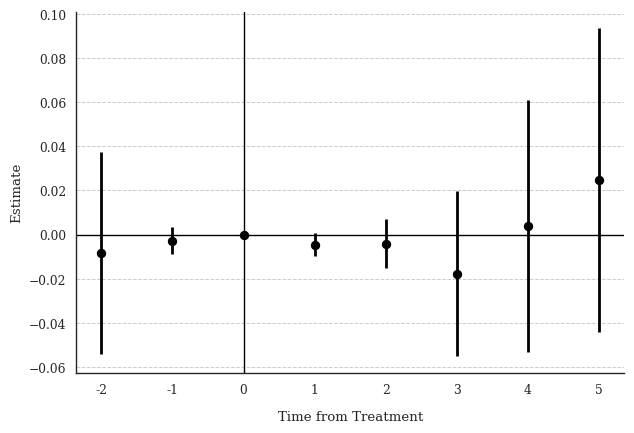

In [61]:
DID(df_rnp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_rp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ui_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ud_transactionnel, 'leg', 1997, 'RN',seuil)

##### 30%

In [62]:
seuil = 1 + 0.3

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000124 0.000731 -0.001557  0.001309 36840.0     8859.0 36840.0       8859.0
            Effect_2  0.000948 0.001061 -0.001131  0.003028 25837.0     7126.0 25837.0       7126.0
            Effect_3  0.000152 0.001515 -0.002817  0.003122 16392.0     5475.0 16392.0       5475.0
            Effect_4 -0.006623 0.001870 -0.010288 -0.002958  8621.0     3032.0  8621.0       3032.0
            Effect_5 -0.012202 0.002929 -0.017942 -0.006462  3512.0     1594.0  3512.0       1594.0
Average_Total_Effect -0.001267 0.000995 -0.003217  0.000683 54082.0    26086.0 54082.0      26086.0
           Placebo_1 -0.000796 0.000763 -0.002290  0.000699 25929.0     7232.0 25929.0       7232.0
           Placebo_2 -0.001015 0.001156 -0.003281  0.001251  9616.0     4032.0  9616.0       4032.0
Test of joint nullity of the effec

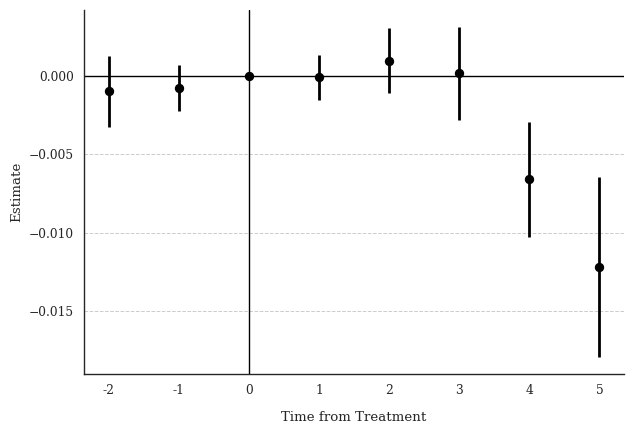

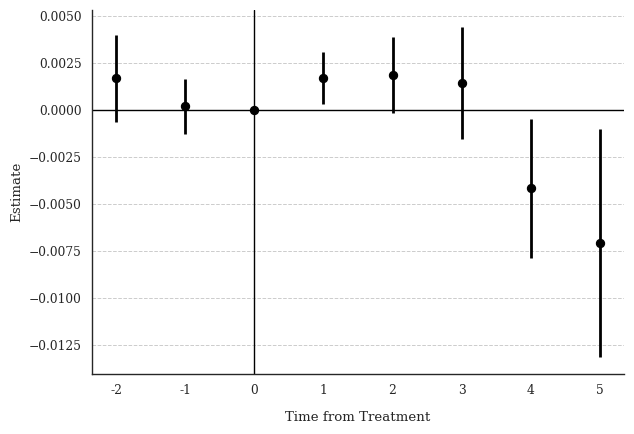

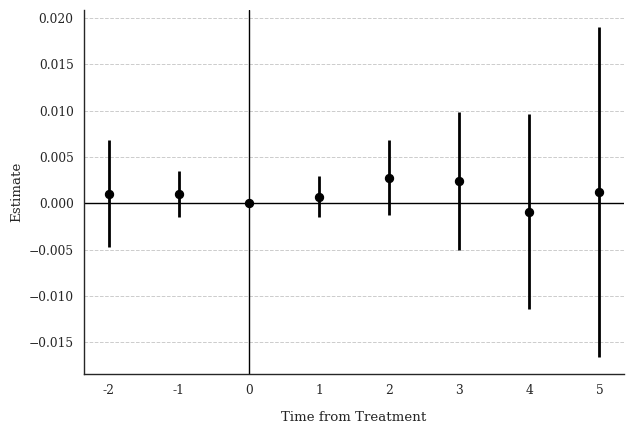

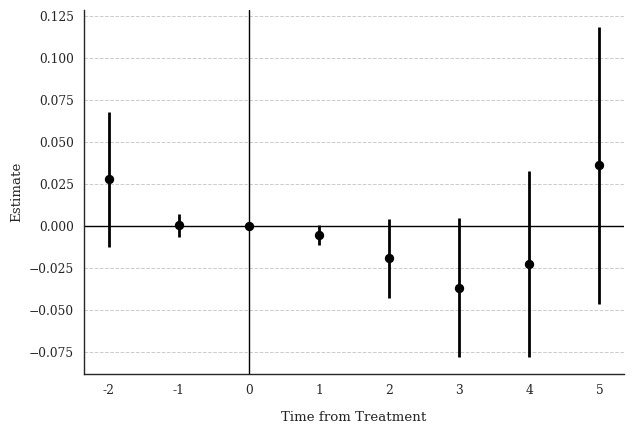

In [63]:
DID(df_rnp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_rp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ui_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ud_transactionnel, 'leg', 1997, 'RN',seuil)

##### 10%

In [64]:
seuil = 1 + 0.1

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000462 0.000739 -0.001911  0.000987 35430.0     8798.0 35430.0       8798.0
            Effect_2  0.000751 0.001068 -0.001342  0.002843 24890.0     7108.0 24890.0       7108.0
            Effect_3 -0.000181 0.001519 -0.003157  0.002796 15876.0     5537.0 15876.0       5537.0
            Effect_4 -0.007793 0.001865 -0.011447 -0.004139  8456.0     3185.0  8456.0       3185.0
            Effect_5 -0.013290 0.002923 -0.019020 -0.007560  3595.0     1815.0  3595.0       1815.0
Average_Total_Effect -0.001841 0.001019 -0.003837  0.000156 53089.0    26443.0 53089.0      26443.0
           Placebo_1 -0.000789 0.000792 -0.002341  0.000762 24718.0     6950.0 24718.0       6950.0
           Placebo_2 -0.001387 0.001200 -0.003739  0.000965  9128.0     3861.0  9128.0       3861.0
Test of joint nullity of the effec

c:\Users\yancr\anaconda3\envs\notebook\Lib\site-packages\did_multiplegt_dyn\did_multiplegt_main.py:3513: UserWarning: The F-test may not be reliable, because the variance of effects is close to not being invertible (the ratio of its largest and smallest eigenvalues is 2122.1, which is larger than 1000). This can for instance happen when you compute many estimators, or when your estimates are very strongly correlated. We recommend that you complement the F-test with a sup t-test, see FAQ section of the help file for more details.
  warnings.warn(matrix_warning, UserWarning)


             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI      N  Switchers    N.w  Switchers.w
            Effect_1 -0.004036 0.002459 -0.008856 0.000784 1001.0      613.0 1001.0        613.0
            Effect_2 -0.006653 0.004891 -0.016239 0.002934  730.0      611.0  730.0        611.0
            Effect_3 -0.008395 0.019582 -0.046774 0.029985  616.0      599.0  616.0        599.0
            Effect_4  0.019020 0.044947 -0.069074 0.107115  514.0      511.0  514.0        511.0
            Effect_5  0.063575 0.063605 -0.061088 0.188238  345.0      344.0  345.0        344.0
Average_Total_Effect  0.007477 0.020051 -0.031822 0.046776 3066.0     2678.0 3066.0       2678.0
           Placebo_1  0.001076 0.004099 -0.006959 0.009110  387.0      268.0  387.0        268.0
           Placebo_2 -0.020038 0.044767 -0.107779 0.067704  103.0      100.0  103.0        100.0
Test of joint nullity of the effects: p-value = 0.212166
Test

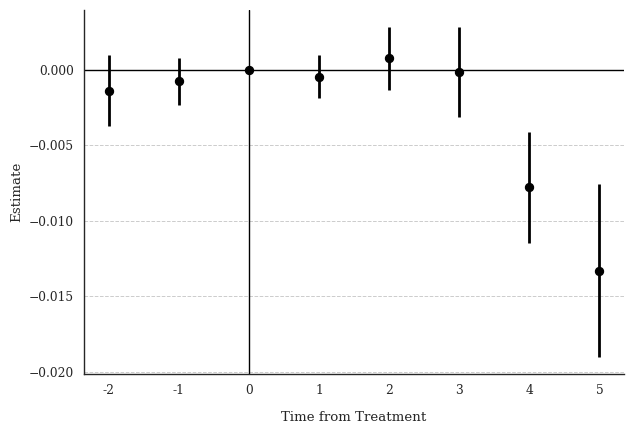

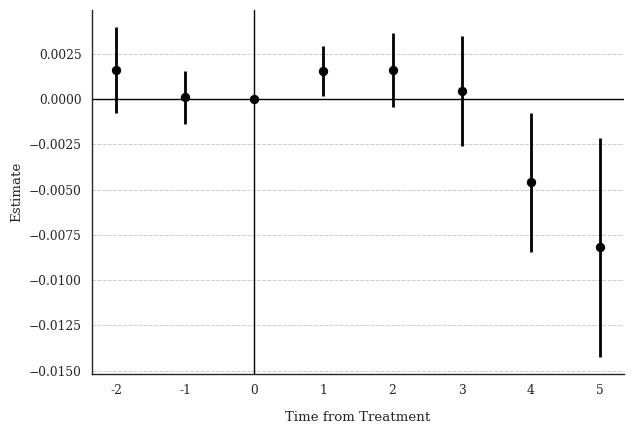

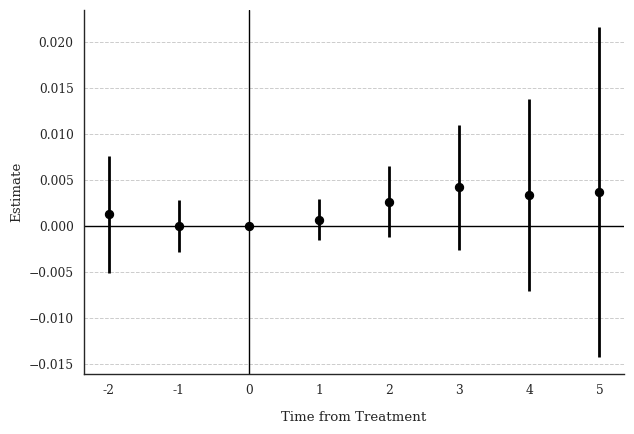

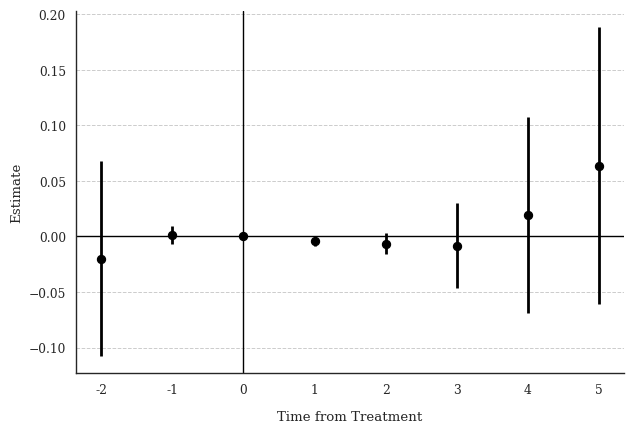

In [65]:
DID(df_rnp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_rp_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ui_transactionnel, 'leg', 1997, 'RN',seuil)
DID(df_ud_transactionnel, 'leg', 1997, 'RN',seuil)

### PS

#### Presidentielles

In [66]:
seuil = 1 + 0.2

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000025 0.000648 -0.001295  0.001245 36289.0     9007.0 36289.0       9007.0
            Effect_2 -0.001148 0.001056 -0.003217  0.000921 25507.0     7304.0 25507.0       7304.0
            Effect_3 -0.003736 0.001289 -0.006262 -0.001209 16296.0     5697.0 16296.0       5697.0
            Effect_4 -0.004459 0.001534 -0.007465 -0.001453  8710.0     3289.0  8710.0       3289.0
            Effect_5 -0.009731 0.002436 -0.014507 -0.004956  3736.0     1875.0  3736.0       1875.0
Average_Total_Effect -0.002311 0.000899 -0.004073 -0.000549 54467.0    27172.0 54467.0      27172.0
           Placebo_1 -0.000392 0.000868 -0.002094  0.001309 25293.0     7103.0 25293.0       7103.0
           Placebo_2 -0.000329 0.001346 -0.002968  0.002310  9355.0     3940.0  9355.0       3940.0
Test of joint nullity of the effec

c:\Users\yancr\anaconda3\envs\notebook\Lib\site-packages\did_multiplegt_dyn\did_multiplegt_main.py:3513: UserWarning: The F-test may not be reliable, because the variance of effects is close to not being invertible (the ratio of its largest and smallest eigenvalues is 6092.0, which is larger than 1000). This can for instance happen when you compute many estimators, or when your estimates are very strongly correlated. We recommend that you complement the F-test with a sup t-test, see FAQ section of the help file for more details.
  warnings.warn(matrix_warning, UserWarning)


             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.002204 0.002264 -0.002235 0.006642 1375.0      677.0 1375.0        677.0
            Effect_2  0.002402 0.012258 -0.021624 0.026428  929.0      675.0  929.0        675.0
            Effect_3 -0.003605 0.027943 -0.058372 0.051162  683.0      650.0  683.0        650.0
            Effect_4 -0.024828 0.045142 -0.113304 0.063649  462.0      457.0  462.0        457.0
            Effect_5 -0.026744 0.074731 -0.173214 0.119726  236.0      234.0  236.0        234.0
Average_Total_Effect -0.006251 0.023901 -0.053095 0.040593 3391.0     2693.0 3391.0       2693.0
           Placebo_1  0.003072 0.003731 -0.004240 0.010384  696.0      442.0  696.0        442.0
           Placebo_2  0.036676 0.008859  0.019313 0.054040  223.0      218.0  223.0        218.0
Test of joint nullity of the effects: p-value = 0.123313
Test

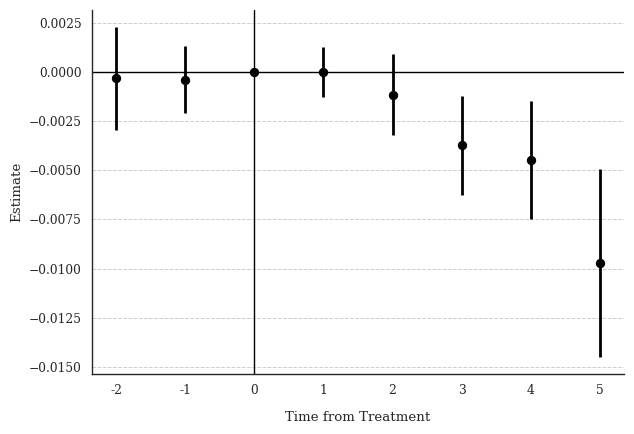

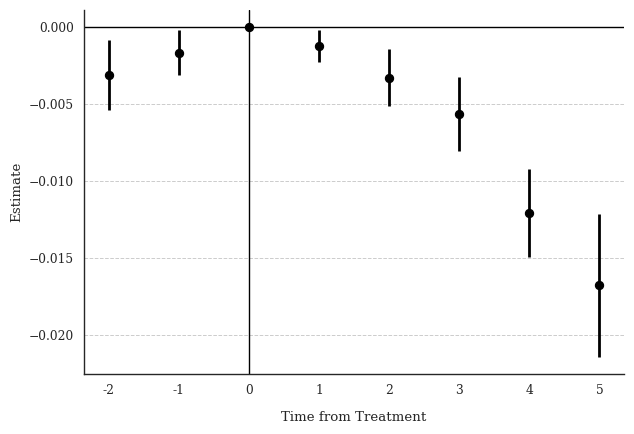

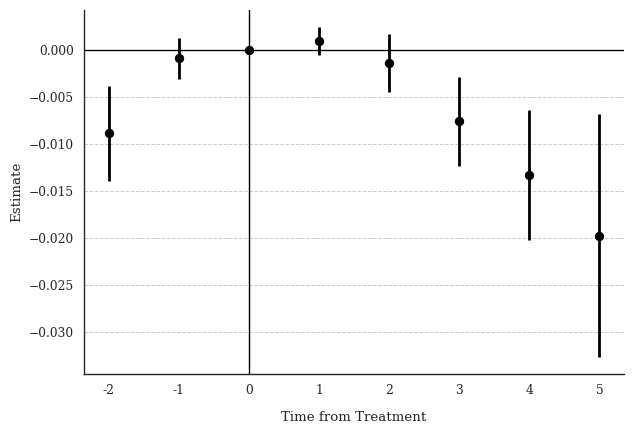

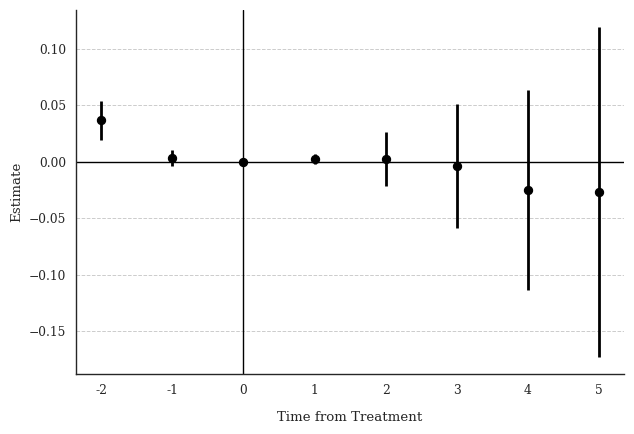

In [67]:
DID(df_rnp_transactionnel, 'pres', 1995, 'PS',seuil)
DID(df_rp_transactionnel, 'pres', 1995, 'PS',seuil)
DID(df_ui_transactionnel, 'pres', 1995, 'PS',seuil)
DID(df_ud_transactionnel, 'pres', 1995, 'PS',seuil)

#### Legislatives

In [68]:
seuil = 1 + 0.2

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.001867 0.001699 -0.001463 0.005198 36158.0     8856.0 36158.0       8856.0
            Effect_2 -0.004279 0.002390 -0.008964 0.000406 25385.0     7155.0 25385.0       7155.0
            Effect_3 -0.003847 0.002983 -0.009693 0.001999 16155.0     5545.0 16155.0       5545.0
            Effect_4  0.002848 0.003653 -0.004311 0.010007  8558.0     3136.0  8558.0       3136.0
            Effect_5  0.008834 0.005383 -0.001717 0.019385  3571.0     1721.0  3571.0       1721.0
Average_Total_Effect -0.000427 0.002027 -0.004400 0.003546 53729.0    26413.0 53729.0      26413.0
           Placebo_1  0.000882 0.001897 -0.002837 0.004600 25318.0     7102.0 25318.0       7102.0
           Placebo_2 -0.005890 0.003177 -0.012116 0.000337  9375.0     3957.0  9375.0       3957.0
Test of joint nullity of the effects: p-val

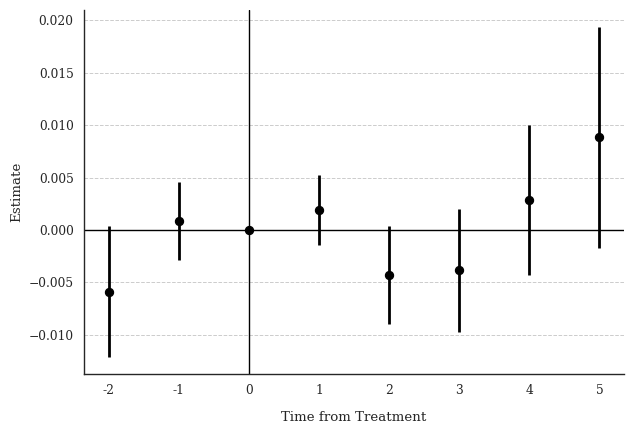

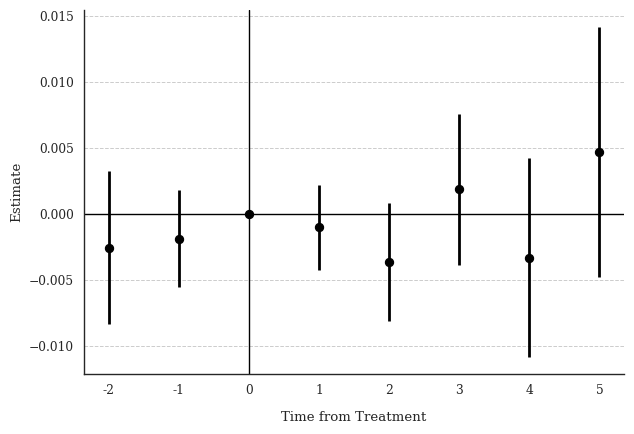

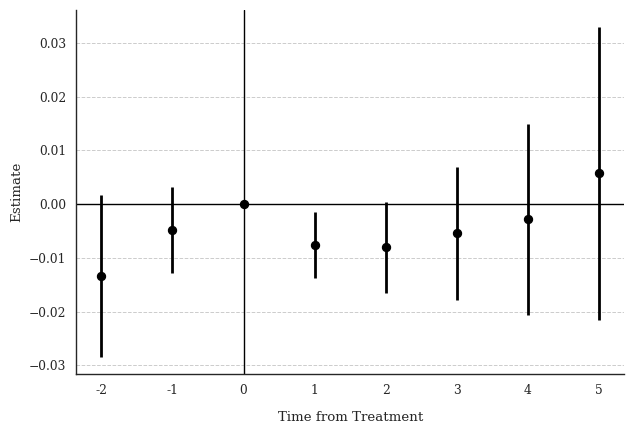

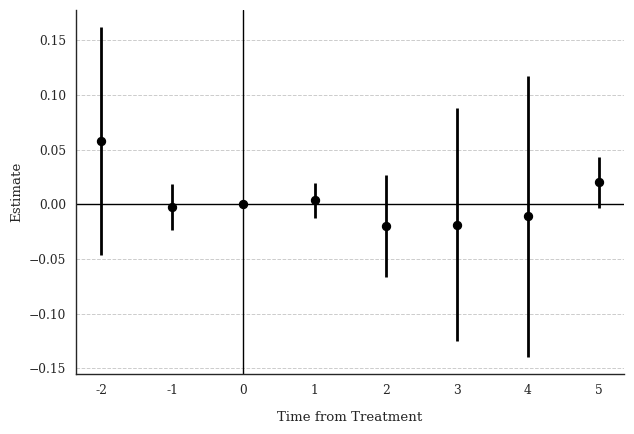

In [69]:
DID(df_rnp_transactionnel, 'leg', 1997, 'PS',seuil)
DID(df_rp_transactionnel, 'leg', 1997, 'PS',seuil)
DID(df_ui_transactionnel, 'leg', 1997, 'PS',seuil)
DID(df_ud_transactionnel, 'leg', 1997, 'PS',seuil)